<a href="https://colab.research.google.com/github/DhushyanthKumar4/Retrieval-engineering-benchmark/blob/main/Generative_AI_Project_Multilingual_Retrieval_Augmented_QA_Benchmarking_System_with_Hybrid_Search%2C_Reranking%2C_and_Latency_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading TyDiQA


README.md:   0%|          | 0.00/11.1k [00:00<?, ?B/s]

primary_task/train-00000-of-00012.parque(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

primary_task/train-00001-of-00012.parque(…):   0%|          | 0.00/225M [00:00<?, ?B/s]

primary_task/train-00002-of-00012.parque(…):   0%|          | 0.00/224M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/18670 [00:00<?, ? examples/s]

Dataset({
    features: ['passage_answer_candidates', 'question_text', 'document_title', 'language', 'annotations', 'document_plaintext', 'document_url'],
    num_rows: 166916
})

Converting sample for semantic analysis...

Creating full metadata dataframe...


Dataset Summary


,Metric,Value
0,Total QA Pairs,166916.000000
1,Total Languages,11.000000
2,Average Question Length,5.491301
3,Average Passage Length,2335.611296
4,Average Document Characters,17810.803835
5,Maximum Passage Length,106469.000000
6,Maximum Question Length,1344.000000




Language Distribution


,count
telugu,24558
arabic,23092
swahili,17613
japanese,16288
finnish,15285
indonesian,14952
russian,12803
thai,11365
korean,10981
bengali,10768


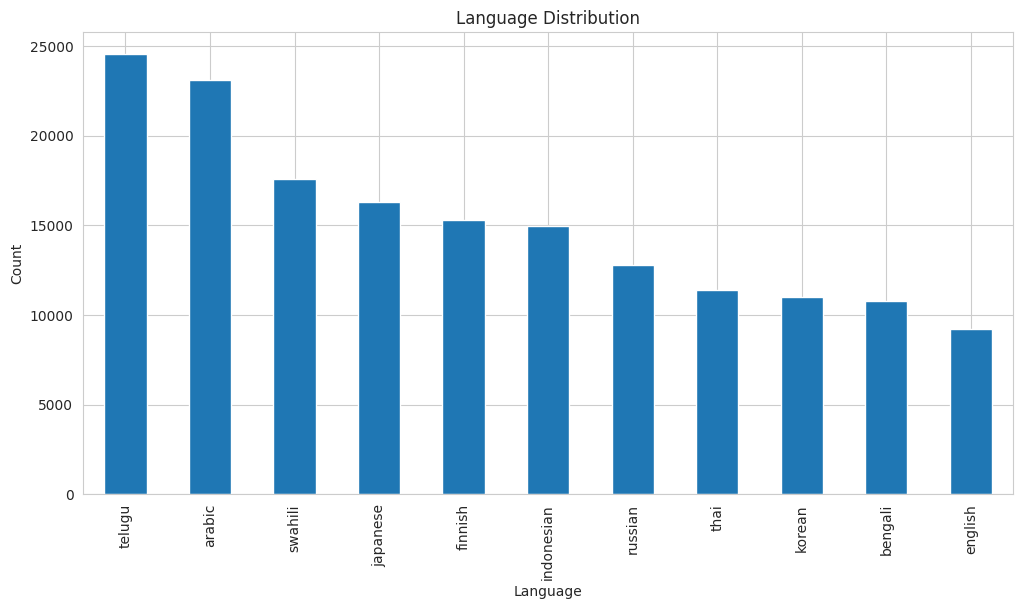



Question Length Distribution


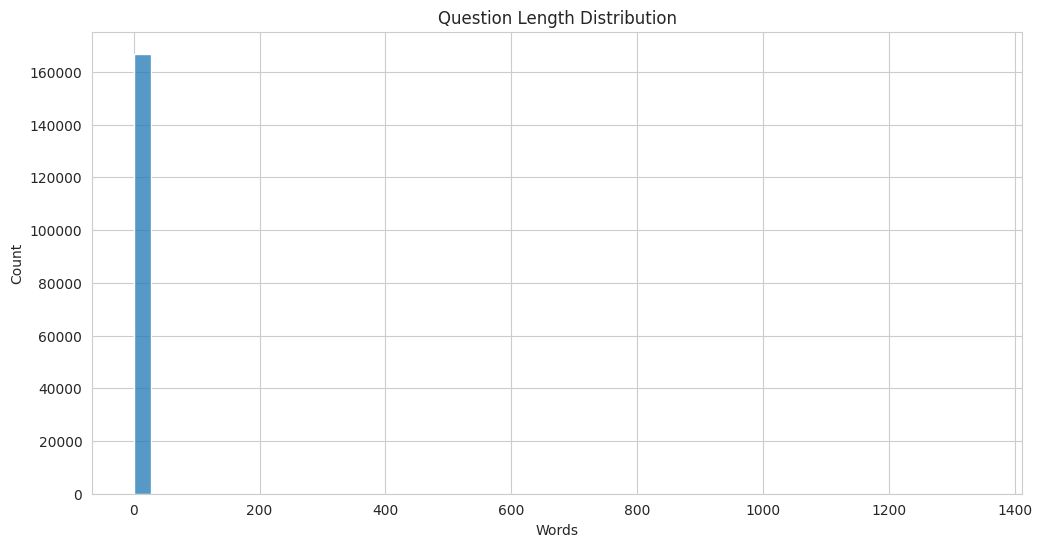



Document Length Distribution


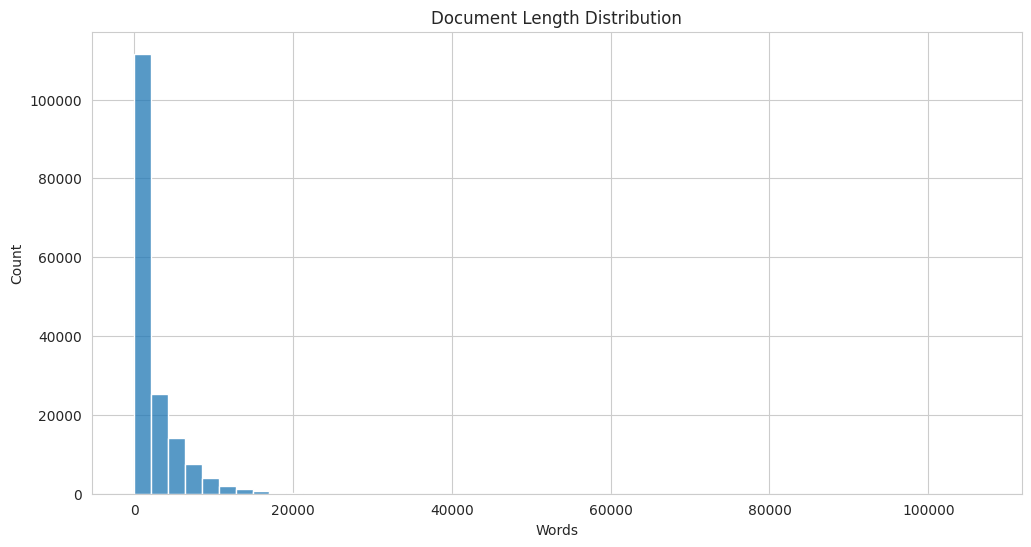



Long Document Analysis
Documents > 1000 words: 52.82%


Chunking Complexity Analysis
Average Chunks Per Document: 9.63
Maximum Chunks Per Document: 416


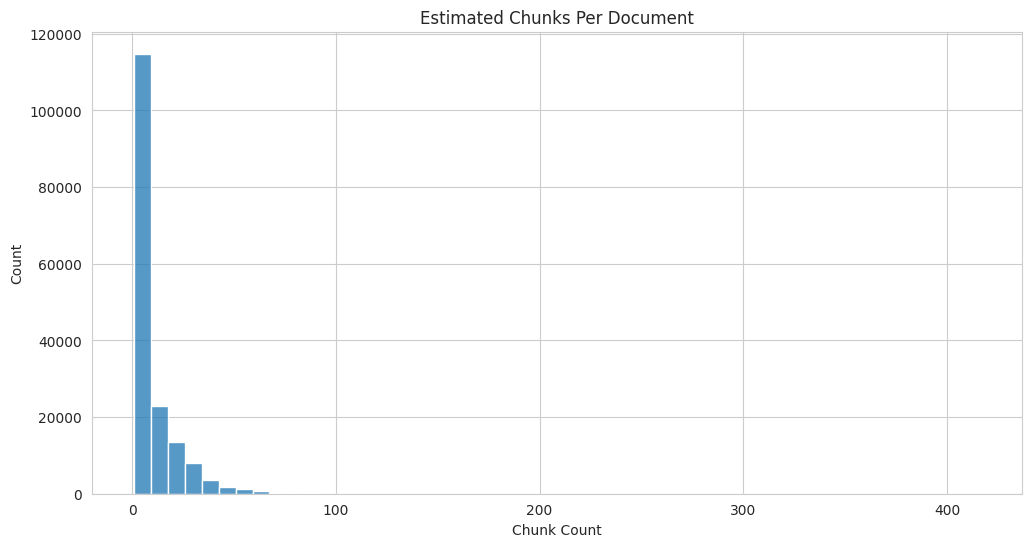



Semantic Structure Analysis


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]


Average Question-Document Similarity: 0.5337


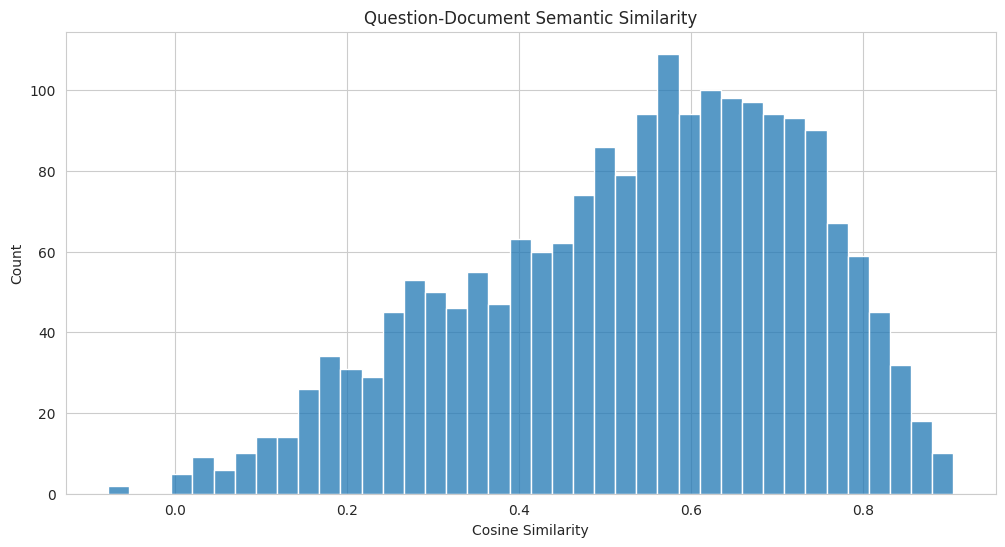



Embedding Cluster Visualization


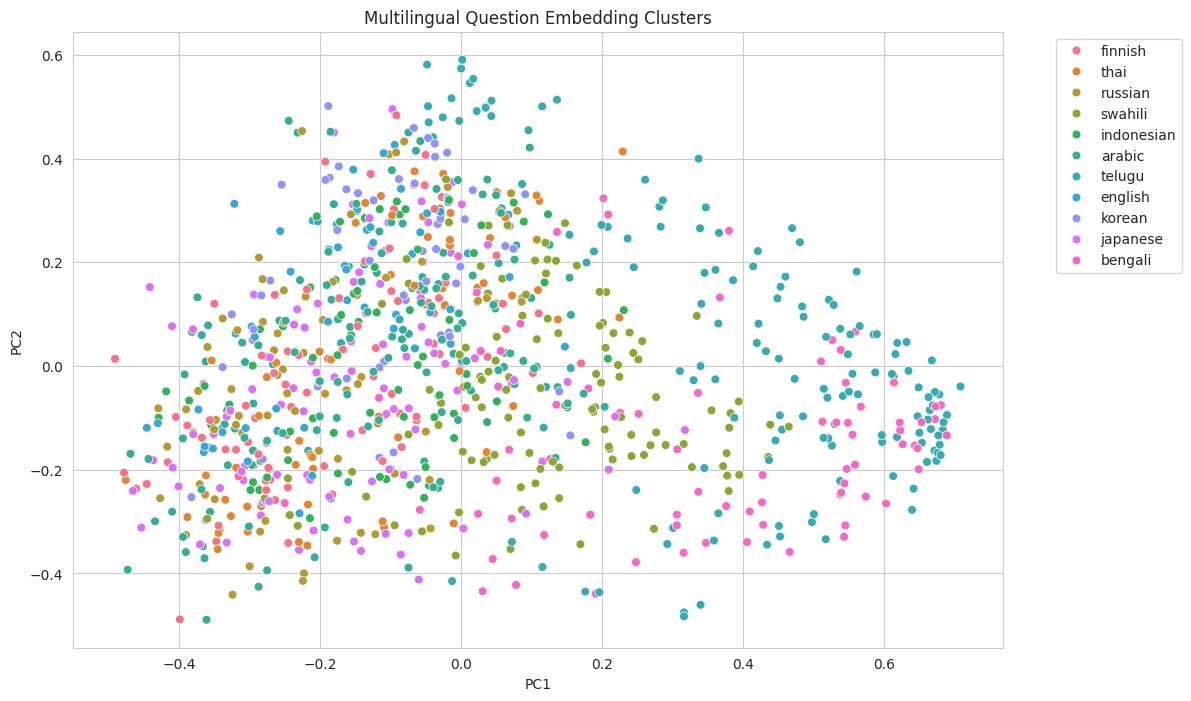



Vocabulary Overlap Analysis


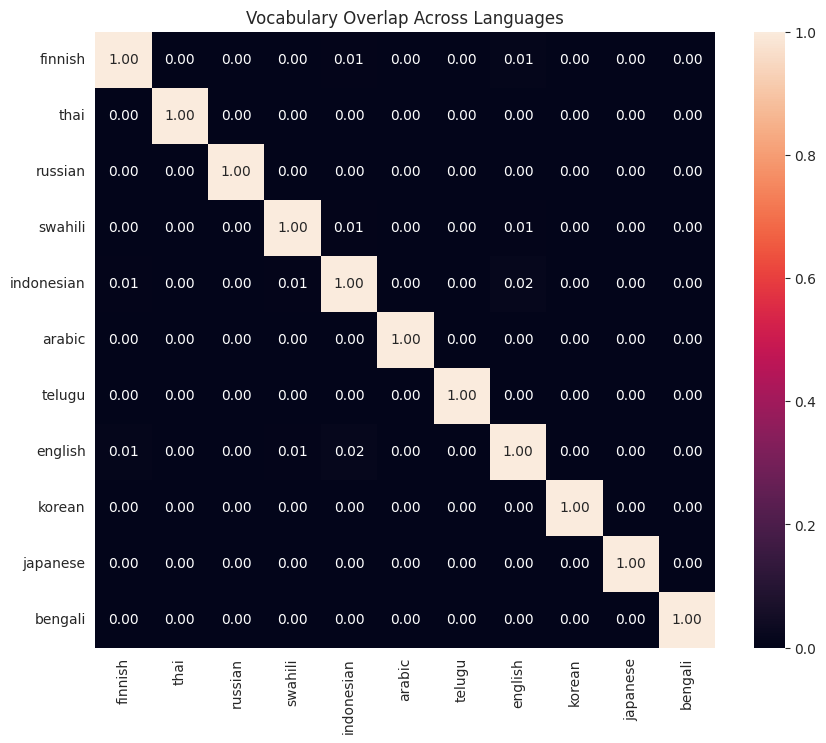



Hypothesis Validation

1. Dense Retrieval is expected to outperform BM25
   because semantic similarity exists across languages.

2. Hybrid Retrieval should improve recall
   by combining lexical and semantic matching.

3. Long documents generate many chunks,
   increasing retrieval complexity.

4. Multilingual embedding clusters indicate
   strong cross-lingual retrieval potential.

5. Retrieval benchmarking is necessary because
   language distributions are highly imbalanced.


EDA Completed Successfully


In [ ]:
# STEP 1 — Data Understanding & EDA

!pip -q install datasets sentence-transformers seaborn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")

print("="*80)
print("Loading TyDiQA")
print("="*80)

dataset = load_dataset(
    "google-research-datasets/tydiqa",
    "primary_task",
    split="train"
)

print(dataset)

print("\nConverting sample for semantic analysis...")

semantic_sample_size = 2000

semantic_df = (
    dataset
    .shuffle(seed=42)
    .select(range(semantic_sample_size))
    .to_pandas()
)

print("\nCreating full metadata dataframe...")

languages = dataset["language"]

question_lengths = [
    len(str(q).split())
    for q in dataset["question_text"]
]

document_lengths = [
    len(str(doc).split())
    for doc in dataset["document_plaintext"]
]

document_char_lengths = [
    len(str(doc))
    for doc in dataset["document_plaintext"]
]

eda_summary = pd.DataFrame({

    "Metric":[
        "Total QA Pairs",
        "Total Languages",
        "Average Question Length",
        "Average Passage Length",
        "Average Document Characters",
        "Maximum Passage Length",
        "Maximum Question Length"
    ],

    "Value":[
        len(dataset),
        len(set(languages)),
        np.mean(question_lengths),
        np.mean(document_lengths),
        np.mean(document_char_lengths),
        np.max(document_lengths),
        np.max(question_lengths)
    ]
})

print("\n")
print("="*80)
print("Dataset Summary")
print("="*80)

display(eda_summary)

print("\n")
print("="*80)
print("Language Distribution")
print("="*80)

language_counts = (
    pd.Series(languages)
    .value_counts()
    .sort_values(ascending=False)
)

display(language_counts)

plt.figure(figsize=(12,6))
language_counts.plot(kind="bar")
plt.title("Language Distribution")
plt.ylabel("Count")
plt.xlabel("Language")
plt.show()

print("\n")
print("="*80)
print("Question Length Distribution")
print("="*80)

plt.figure(figsize=(12,6))
sns.histplot(
    question_lengths,
    bins=50
)
plt.title("Question Length Distribution")
plt.xlabel("Words")
plt.show()

print("\n")
print("="*80)
print("Document Length Distribution")
print("="*80)

plt.figure(figsize=(12,6))
sns.histplot(
    document_lengths,
    bins=50
)
plt.title("Document Length Distribution")
plt.xlabel("Words")
plt.show()

print("\n")
print("="*80)
print("Long Document Analysis")
print("="*80)

long_doc_threshold = 1000

long_doc_pct = (
    np.mean(
        np.array(document_lengths)
        > long_doc_threshold
    )
    * 100
)

print(
    f"Documents > {long_doc_threshold} words: "
    f"{long_doc_pct:.2f}%"
)

print("\n")
print("="*80)
print("Chunking Complexity Analysis")
print("="*80)

chunk_size = 256

chunk_counts = [
    int(np.ceil(x/chunk_size))
    for x in document_lengths
]

print(
    f"Average Chunks Per Document: "
    f"{np.mean(chunk_counts):.2f}"
)

print(
    f"Maximum Chunks Per Document: "
    f"{np.max(chunk_counts)}"
)

plt.figure(figsize=(12,6))
sns.histplot(
    chunk_counts,
    bins=50
)
plt.title(
    "Estimated Chunks Per Document"
)
plt.xlabel("Chunk Count")
plt.show()

print("\n")
print("="*80)
print("Semantic Structure Analysis")
print("="*80)

model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

sample_questions = (
    semantic_df["question_text"]
    .fillna("")
    .astype(str)
    .tolist()
)

sample_docs = (
    semantic_df["document_plaintext"]
    .fillna("")
    .astype(str)
    .str[:1000]
    .tolist()
)

question_embeddings = model.encode(
    sample_questions,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

document_embeddings = model.encode(
    sample_docs,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

semantic_similarity = np.sum(
    question_embeddings *
    document_embeddings,
    axis=1
)

print(
    f"\nAverage Question-Document Similarity: "
    f"{semantic_similarity.mean():.4f}"
)

plt.figure(figsize=(12,6))
sns.histplot(
    semantic_similarity,
    bins=40
)
plt.title(
    "Question-Document Semantic Similarity"
)
plt.xlabel("Cosine Similarity")
plt.show()

print("\n")
print("="*80)
print("Embedding Cluster Visualization")
print("="*80)

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(
    question_embeddings[:1000]
)

plot_df = pd.DataFrame({

    "PC1": reduced_embeddings[:,0],
    "PC2": reduced_embeddings[:,1],
    "language": semantic_df[
        "language"
    ].iloc[:1000].values

})

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="language",
    s=40
)

plt.title(
    "Multilingual Question Embedding Clusters"
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.show()

print("\n")
print("="*80)
print("Vocabulary Overlap Analysis")
print("="*80)

language_vocab = {}

sample_vocab_df = (
    semantic_df
    .groupby("language")
    .head(200)
)

for lang in sample_vocab_df[
    "language"
].unique():

    text = " ".join(

        sample_vocab_df[
            sample_vocab_df["language"]
            == lang
        ]["question_text"]
        .astype(str)
        .tolist()

    )

    language_vocab[lang] = set(
        text.lower().split()
    )

languages_list = list(
    language_vocab.keys()
)

overlap_matrix = []

for lang1 in languages_list:

    row = []

    for lang2 in languages_list:

        intersection = len(
            language_vocab[lang1]
            &
            language_vocab[lang2]
        )

        union = len(
            language_vocab[lang1]
            |
            language_vocab[lang2]
        )

        row.append(
            intersection/union
            if union > 0
            else 0
        )

    overlap_matrix.append(row)

overlap_df = pd.DataFrame(
    overlap_matrix,
    index=languages_list,
    columns=languages_list
)

plt.figure(figsize=(10,8))

sns.heatmap(
    overlap_df,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Vocabulary Overlap Across Languages"
)

plt.show()

print("\n")
print("="*80)
print("Hypothesis Validation")
print("="*80)

print("""
1. Dense Retrieval is expected to outperform BM25
   because semantic similarity exists across languages.

2. Hybrid Retrieval should improve recall
   by combining lexical and semantic matching.

3. Long documents generate many chunks,
   increasing retrieval complexity.

4. Multilingual embedding clusters indicate
   strong cross-lingual retrieval potential.

5. Retrieval benchmarking is necessary because
   language distributions are highly imbalanced.
""")

print("\nEDA Completed Successfully")

In [ ]:
# STEP 2 — Data Cleaning & Document Processing

!pip -q install datasets

import re
import unicodedata
import pandas as pd
from datasets import load_dataset

print("="*80)
print("Loading TyDiQA")
print("="*80)

dataset = load_dataset(
    "google-research-datasets/tydiqa",
    "primary_task",
    split="train[:30000]"
)

df = dataset.to_pandas()

print(f"\nOriginal Rows: {len(df):,}")

print("\n" + "="*80)
print("Unicode Normalization")
print("="*80)

def normalize_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = unicodedata.normalize(
        "NFKC",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

text_columns = [
    "question_text",
    "document_plaintext",
    "document_title"
]

for col in text_columns:

    df[col] = df[col].apply(
        normalize_text
    )

print("\n" + "="*80)
print("Removing Corrupted Rows")
print("="*80)

before = len(df)

df = df[
    df["question_text"].notna()
]

df = df[
    df["document_plaintext"].notna()
]

df = df[
    df["language"].notna()
]

after = len(df)

print(
    f"Removed: {before-after:,}"
)

print("\n" + "="*80)
print("Removing Empty Documents")
print("="*80)

before = len(df)

df = df[
    df["question_text"].str.len() > 0
]

df = df[
    df["document_plaintext"].str.len() > 0
]

after = len(df)

print(
    f"Removed: {before-after:,}"
)

print("\n" + "="*80)
print("Removing Extremely Small Documents")
print("="*80)

before = len(df)

df["document_word_count"] = (
    df["document_plaintext"]
    .str.split()
    .str.len()
)

df = df[
    df["document_word_count"] >= 20
]

after = len(df)

print(
    f"Removed: {before-after:,}"
)

print("\n" + "="*80)
print("Removing Duplicate Documents")
print("="*80)

before = len(df)

df = df.drop_duplicates(
    subset=[
        "document_plaintext"
    ]
)

after = len(df)

print(
    f"Removed: {before-after:,}"
)

print("\n" + "="*80)
print("Removing Duplicate Question-Document Pairs")
print("="*80)

before = len(df)

df = df.drop_duplicates(
    subset=[
        "question_text",
        "document_plaintext"
    ]
)

after = len(df)

print(
    f"Removed: {before-after:,}"
)

print("\n" + "="*80)
print("Basic Quality Statistics")
print("="*80)

df["question_word_count"] = (
    df["question_text"]
    .str.split()
    .str.len()
)

summary = pd.DataFrame({

    "Metric":[
        "Final Rows",
        "Languages",
        "Avg Question Length",
        "Avg Document Length",
        "Max Document Length"
    ],

    "Value":[
        len(df),
        df["language"].nunique(),
        round(
            df["question_word_count"].mean(),
            2
        ),
        round(
            df["document_word_count"].mean(),
            2
        ),
        int(
            df["document_word_count"].max()
        )
    ]
})

display(summary)

print("\n" + "="*80)
print("Language Distribution")
print("="*80)

display(
    df["language"]
    .value_counts()
)

print("\n" + "="*80)
print("Saving Clean Corpus")
print("="*80)

df = df.reset_index(
    drop=True
)

df.to_parquet(
    "clean_tydiqa.parquet",
    index=False
)

df.to_csv(
    "clean_tydiqa.csv",
    index=False
)

print(
    f"\nClean Dataset Shape: {df.shape}"
)

print(
    "\nSaved Files:"
)

print(
    "clean_tydiqa.parquet"
)

print(
    "clean_tydiqa.csv"
)

print("\nStep 2 Completed Successfully")

Loading TyDiQA

Original Rows: 30,000

Unicode Normalization

Removing Corrupted Rows
Removed: 0

Removing Empty Documents
Removed: 0

Removing Extremely Small Documents
Removed: 146

Removing Duplicate Documents
Removed: 8,276

Removing Duplicate Question-Document Pairs
Removed: 0

Basic Quality Statistics


,Metric,Value
0,Final Rows,21578.00
1,Languages,11.00
2,Avg Question Length,5.35
3,Avg Document Length,2050.93
4,Max Document Length,61232.00



Language Distribution


,count
language,
arabic,3252
telugu,2710
japanese,2543
finnish,2297
indonesian,2147
russian,1978
english,1572
swahili,1491
thai,1442



Saving Clean Corpus

Clean Dataset Shape: (21578, 9)

Saved Files:
clean_tydiqa.parquet
clean_tydiqa.csv

Step 2 Completed Successfully


In [ ]:
# STEP 3 — Train / Validation / Test Split

!pip -q install scikit-learn

import pandas as pd

from sklearn.model_selection import train_test_split

print("="*80)
print("Loading Clean Dataset")
print("="*80)

df = pd.read_parquet(
    "clean_tydiqa.parquet"
)

print(
    f"Total Rows: {len(df):,}"
)

print("\n" + "="*80)
print("Language Distribution Before Split")
print("="*80)

print(
    df["language"]
    .value_counts()
)

print("\n" + "="*80)
print("Creating Train / Validation / Test Split")
print("="*80)

RANDOM_STATE = 42

train_df, temp_df = train_test_split(

    df,

    test_size=0.30,

    stratify=df["language"],

    random_state=RANDOM_STATE

)

valid_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    stratify=temp_df["language"],

    random_state=RANDOM_STATE

)

print(
    f"Train Size: {len(train_df):,}"
)

print(
    f"Validation Size: {len(valid_df):,}"
)

print(
    f"Test Size: {len(test_df):,}"
)

print("\n" + "="*80)
print("Split Ratios")
print("="*80)

print(
    f"Train: {len(train_df)/len(df)*100:.2f}%"
)

print(
    f"Validation: {len(valid_df)/len(df)*100:.2f}%"
)

print(
    f"Test: {len(test_df)/len(df)*100:.2f}%"
)

print("\n" + "="*80)
print("Language Distribution Check")
print("="*80)

distribution_df = pd.DataFrame({

    "Full Dataset":
        df["language"].value_counts(),

    "Train":
        train_df["language"].value_counts(),

    "Validation":
        valid_df["language"].value_counts(),

    "Test":
        test_df["language"].value_counts()

}).fillna(0).astype(int)

display(
    distribution_df
)

print("\n" + "="*80)
print("Saving Splits")
print("="*80)

train_df = train_df.reset_index(
    drop=True
)

valid_df = valid_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

train_df.to_parquet(
    "train.parquet",
    index=False
)

valid_df.to_parquet(
    "validation.parquet",
    index=False
)

test_df.to_parquet(
    "test.parquet",
    index=False
)

train_df.to_csv(
    "train.csv",
    index=False
)

valid_df.to_csv(
    "validation.csv",
    index=False
)

test_df.to_csv(
    "test.csv",
    index=False
)

print(
    "\nSaved Files:"
)

print(
    "train.parquet"
)

print(
    "validation.parquet"
)

print(
    "test.parquet"
)

print(
    "train.csv"
)

print(
    "validation.csv"
)

print(
    "test.csv"
)

print("\n" + "="*80)
print("Final Summary")
print("="*80)

summary = pd.DataFrame({

    "Split":[
        "Train",
        "Validation",
        "Test"
    ],

    "Rows":[
        len(train_df),
        len(valid_df),
        len(test_df)
    ],

    "Percentage":[
        round(
            len(train_df)/len(df)*100,
            2
        ),

        round(
            len(valid_df)/len(df)*100,
            2
        ),

        round(
            len(test_df)/len(df)*100,
            2
        )
    ]

})

display(summary)

print(
    "\nStep 3 Completed Successfully"
)

Loading Clean Dataset
Total Rows: 21,578

Language Distribution Before Split
language
arabic        3252
telugu        2710
japanese      2543
finnish       2297
indonesian    2147
russian       1978
english       1572
swahili       1491
thai          1442
korean        1099
bengali       1047
Name: count, dtype: int64

Creating Train / Validation / Test Split
Train Size: 15,104
Validation Size: 3,237
Test Size: 3,237

Split Ratios
Train: 70.00%
Validation: 15.00%
Test: 15.00%

Language Distribution Check


,Full Dataset,Train,Validation,Test
language,,,,
arabic,3252,2276,488,488
telugu,2710,1897,406,407
japanese,2543,1780,382,381
finnish,2297,1608,345,344
indonesian,2147,1503,322,322
russian,1978,1385,296,297
english,1572,1100,236,236
swahili,1491,1044,223,224
thai,1442,1009,217,216



Saving Splits

Saved Files:
train.parquet
validation.parquet
test.parquet
train.csv
validation.csv
test.csv

Final Summary


,Split,Rows,Percentage
0,Train,15104,70.0
1,Validation,3237,15.0
2,Test,3237,15.0



Step 3 Completed Successfully


In [ ]:
# STEP 4 — Retrieval Preprocessing Pipeline

!pip -q install pyarrow tqdm

import gc
import math
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from tqdm.auto import tqdm

print("="*80)
print("Loading Training Split")
print("="*80)

train_df = pd.read_parquet(
    "train.parquet"
)

print(
    f"Training Documents: {len(train_df):,}"
)

print("\n" + "="*80)
print("Fixed Chunk Configuration")
print("="*80)

CHUNK_SIZE = 256
OVERLAP = 50

print(
    f"Chunk Size: {CHUNK_SIZE}"
)

print(
    f"Overlap: {OVERLAP}"
)

def fixed_chunk_text(
    text,
    chunk_size=256,
    overlap=50
):

    if not isinstance(text, str):
        return []

    words = text.split()

    if len(words) == 0:
        return []

    chunks = []

    start = 0

    while start < len(words):

        end = start + chunk_size

        chunk = " ".join(
            words[start:end]
        )

        chunks.append(
            chunk
        )

        start += (
            chunk_size - overlap
        )

    return chunks

print("\n" + "="*80)
print("Streaming Chunk Generation")
print("="*80)

OUTPUT_FILE = (
    "retrieval_corpus.parquet"
)

BATCH_SIZE = 5000

writer = None

batch_records = []

total_chunks = 0

for document_id, row in tqdm(
    train_df.iterrows(),
    total=len(train_df)
):

    chunks = fixed_chunk_text(
        row["document_plaintext"],
        CHUNK_SIZE,
        OVERLAP
    )

    for chunk_id, chunk in enumerate(
        chunks
    ):

        batch_records.append({

            "document_id":
                int(document_id),

            "chunk_id":
                int(chunk_id),

            "chunk_position":
                round(
                    chunk_id /
                    max(len(chunks), 1),
                    4
                ),

            "chunk_text":
                chunk,

            "language":
                row["language"],

            "document_title":
                row["document_title"]

        })

        total_chunks += 1

    if len(batch_records) >= BATCH_SIZE:

        batch_df = pd.DataFrame(
            batch_records
        )

        table = pa.Table.from_pandas(
            batch_df,
            preserve_index=False
        )

        if writer is None:

            writer = pq.ParquetWriter(
                OUTPUT_FILE,
                table.schema
            )

        writer.write_table(
            table
        )

        batch_records = []

        gc.collect()

if len(batch_records) > 0:

    batch_df = pd.DataFrame(
        batch_records
    )

    table = pa.Table.from_pandas(
        batch_df,
        preserve_index=False
    )

    if writer is None:

        writer = pq.ParquetWriter(
            OUTPUT_FILE,
            table.schema
        )

    writer.write_table(
        table
    )

if writer:

    writer.close()

print("\n" + "="*80)
print("Chunking Completed")
print("="*80)

print(
    f"Total Chunks Created: {total_chunks:,}"
)

print(
    f"Output File: {OUTPUT_FILE}"
)

print("\n" + "="*80)
print("Quick Validation")
print("="*80)

sample_df = pd.read_parquet(
    OUTPUT_FILE
)

print(
    f"Stored Chunks: {len(sample_df):,}"
)

display(
    sample_df.head()
)

avg_chunks = (
    len(sample_df)
    /
    len(train_df)
)

print(
    f"\nAverage Chunks Per Document: "
    f"{avg_chunks:.2f}"
)

print("\nStep 4 Completed Successfully")

Loading Training Split
Training Documents: 15,104

Fixed Chunk Configuration
Chunk Size: 256
Overlap: 50

Streaming Chunk Generation


  0%|          | 0/15104 [00:00<?, ?it/s]


Chunking Completed
Total Chunks Created: 157,241
Output File: retrieval_corpus.parquet

Quick Validation
Stored Chunks: 157,241


,document_id,chunk_id,chunk_position,chunk_text,language,document_title
0,0,0,0.0000,雇用保険(こようほけん)とは、日本における雇用保険法に基づく、失業・雇用継続等に関する保険の...,japanese,雇用保険
1,0,1,0.3333,受給資格決定時において以下のいずれかに該当する者は、「就職困難者」として扱われる(第22条2...,japanese,雇用保険
2,0,2,0.6667,求人者との面接・対象となる教育訓練等のためにその子に対して保育等サービスを利用する場合[25...,japanese,雇用保険
3,1,0,0.0000,Galileo Galilei (Italian pronunciation:[ɡaliˈl...,indonesian,Galileo Galilei
4,1,1,0.2500,kebebasan berpikir (terutama dalam sains) pada...,indonesian,Galileo Galilei



Average Chunks Per Document: 10.41

Step 4 Completed Successfully


In [ ]:
chunks_df = pd.read_parquet(
    "retrieval_corpus.parquet"
)

chunks_df = (
    chunks_df
    .groupby("language", group_keys=False)
    .apply(
        lambda x: x.sample(
            min(len(x), 5000),
            random_state=42
        )
    )
)

print(len(chunks_df))

chunks_df.to_parquet(
    "retrieval_corpus_50k.parquet",
    index=False
)

52668


In [ ]:
# STEP 5 — Embedding Pipeline

!pip -q install sentence-transformers

import gc
import os
import time
import torch
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

print("="*80)
print("Loading Retrieval Corpus")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus.parquet"
)

print(
    f"Original Chunks: {len(chunks_df):,}"
)

print("\n" + "="*80)
print("Creating Retrieval Subset")
print("="*80)

MAX_CHUNKS = 50000

if len(chunks_df) > MAX_CHUNKS:

    chunks_df = (
        chunks_df
        .groupby("language", group_keys=False)
        .apply(
            lambda x: x.sample(
                min(
                    len(x),
                    int(MAX_CHUNKS / chunks_df["language"].nunique())
                ),
                random_state=42
            )
        )
        .reset_index(drop=True)
    )

print(
    f"Chunks Used: {len(chunks_df):,}"
)

chunks_df.to_parquet(
    "retrieval_corpus_50k.parquet",
    index=False
)

texts = chunks_df[
    "chunk_text"
].tolist()

print("\n" + "="*80)
print("Loading Embedding Model")
print("="*80)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    f"Device: {device}"
)

model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device=device
)

print(
    "\nModel Loaded Successfully"
)

print("\n" + "="*80)
print("Generating Embeddings")
print("="*80)

BATCH_SIZE = 16

all_embeddings = []

start_time = time.time()

for start in tqdm(
    range(
        0,
        len(texts),
        256
    )
):

    batch = texts[
        start:start+256
    ]

    embeddings = model.encode(

        batch,

        batch_size=BATCH_SIZE,

        normalize_embeddings=True,

        convert_to_numpy=True,

        show_progress_bar=False

    )

    all_embeddings.append(
        embeddings
    )

    torch.cuda.empty_cache()

    gc.collect()

embedding_matrix = np.vstack(
    all_embeddings
)

total_time = (
    time.time()
    -
    start_time
)

chunks_per_second = (
    len(texts)
    /
    total_time
)

print("\n" + "="*80)
print("Embedding Statistics")
print("="*80)

print(
    f"Embedding Shape: {embedding_matrix.shape}"
)

print(
    f"Dimension: {embedding_matrix.shape[1]}"
)

print(
    f"Total Time: {total_time:.2f} sec"
)

print(
    f"Chunks / Second: {chunks_per_second:.2f}"
)

print("\n" + "="*80)
print("Saving Artifacts")
print("="*80)

np.save(
    "multilingual_e5_embeddings.npy",
    embedding_matrix
)

benchmark_df = pd.DataFrame({

    "metric":[
        "total_chunks",
        "embedding_dimension",
        "total_time_seconds",
        "chunks_per_second"
    ],

    "value":[
        len(texts),
        embedding_matrix.shape[1],
        round(total_time,2),
        round(chunks_per_second,2)
    ]
})

benchmark_df.to_csv(
    "embedding_benchmark.csv",
    index=False
)

print(
    "Saved: multilingual_e5_embeddings.npy"
)

print(
    "Saved: embedding_benchmark.csv"
)

print(
    "Saved: retrieval_corpus_50k.parquet"
)

del texts
del all_embeddings

gc.collect()

torch.cuda.empty_cache()

print("\n" + "="*80)
print("Step 5 Completed Successfully")
print("="*80)

Loading Retrieval Corpus
Original Chunks: 157,241

Creating Retrieval Subset
Chunks Used: 48,573

Loading Embedding Model
Device: cuda


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]


Model Loaded Successfully

Generating Embeddings


  0%|          | 0/190 [00:00<?, ?it/s]


Embedding Statistics
Embedding Shape: (48573, 768)
Dimension: 768
Total Time: 1595.40 sec
Chunks / Second: 30.45

Saving Artifacts
Saved: multilingual_e5_embeddings.npy
Saved: embedding_benchmark.csv
Saved: retrieval_corpus_50k.parquet

Step 5 Completed Successfully


In [ ]:
# STEP 6 — Vector Indexing System

!pip -q install faiss-gpu-cu12

import os
import time
import faiss
import numpy as np
import pandas as pd

print("="*80)
print("Loading Embeddings")
print("="*80)

embeddings = np.load(
    "multilingual_e5_embeddings.npy"
).astype(np.float32)

print(
    f"Embedding Shape: {embeddings.shape}"
)

n_vectors = embeddings.shape[0]
dimension = embeddings.shape[1]

print(
    f"Vectors: {n_vectors:,}"
)
print(
    f"Dimension: {dimension}"
)

print("\n" + "="*80)
print("Building Flat Index")
print("="*80)

start = time.time()

flat_index = faiss.IndexFlatIP(
    dimension
)

flat_index.add(
    embeddings
)

flat_build_time = (
    time.time() - start
)

faiss.write_index(
    flat_index,
    "flat_index.faiss"
)

flat_size_mb = (
    os.path.getsize(
        "flat_index.faiss"
    ) / (1024**2)
)

print(
    f"Build Time: {flat_build_time:.2f} sec"
)
print(
    f"Index Size: {flat_size_mb:.2f} MB"
)

print("\n" + "="*80)
print("Building IVF Index")
print("="*80)

nlist = 256

quantizer = faiss.IndexFlatIP(
    dimension
)

ivf_index = faiss.IndexIVFFlat(
    quantizer,
    dimension,
    nlist,
    faiss.METRIC_INNER_PRODUCT
)

start = time.time()

ivf_index.train(
    embeddings
)

ivf_index.add(
    embeddings
)

ivf_build_time = (
    time.time() - start
)

ivf_index.nprobe = 16

faiss.write_index(
    ivf_index,
    "ivf_index.faiss"
)

ivf_size_mb = (
    os.path.getsize(
        "ivf_index.faiss"
    ) / (1024**2)
)

print(
    f"Build Time: {ivf_build_time:.2f} sec"
)

print(
    f"Index Size: {ivf_size_mb:.2f} MB"
)

print("\n" + "="*80)
print("Building HNSW Index")
print("="*80)

start = time.time()

hnsw_index = faiss.IndexHNSWFlat(
    dimension,
    32
)

hnsw_index.hnsw.efConstruction = 200

hnsw_index.add(
    embeddings
)

hnsw_build_time = (
    time.time() - start
)

faiss.write_index(
    hnsw_index,
    "hnsw_index.faiss"
)

hnsw_size_mb = (
    os.path.getsize(
        "hnsw_index.faiss"
    ) / (1024**2)
)

print(
    f"Build Time: {hnsw_build_time:.2f} sec"
)

print(
    f"Index Size: {hnsw_size_mb:.2f} MB"
)

print("\n" + "="*80)
print("Latency Benchmark")
print("="*80)

np.random.seed(42)

query_vectors = embeddings[
    np.random.choice(
        n_vectors,
        100,
        replace=False
    )
]

def benchmark_latency(
    index,
    queries,
    top_k=10
):

    start = time.time()

    index.search(
        queries,
        top_k
    )

    total_time = (
        time.time() - start
    )

    avg_ms = (
        total_time
        /
        len(queries)
    ) * 1000

    return avg_ms

flat_latency = benchmark_latency(
    flat_index,
    query_vectors
)

ivf_latency = benchmark_latency(
    ivf_index,
    query_vectors
)

hnsw_latency = benchmark_latency(
    hnsw_index,
    query_vectors
)

print(
    f"Flat Latency : {flat_latency:.3f} ms"
)

print(
    f"IVF Latency  : {ivf_latency:.3f} ms"
)

print(
    f"HNSW Latency : {hnsw_latency:.3f} ms"
)

print("\n" + "="*80)
print("Benchmark Summary")
print("="*80)

benchmark_df = pd.DataFrame({

    "Index":[
        "Flat",
        "IVF",
        "HNSW"
    ],

    "Build_Time_sec":[
        round(flat_build_time,2),
        round(ivf_build_time,2),
        round(hnsw_build_time,2)
    ],

    "Latency_ms":[
        round(flat_latency,3),
        round(ivf_latency,3),
        round(hnsw_latency,3)
    ],

    "Index_Size_MB":[
        round(flat_size_mb,2),
        round(ivf_size_mb,2),
        round(hnsw_size_mb,2)
    ]
})

print(
    benchmark_df
)

benchmark_df.to_csv(
    "faiss_index_benchmark.csv",
    index=False
)

print("\n" + "="*80)
print("Saved Artifacts")
print("="*80)

print("flat_index.faiss")
print("ivf_index.faiss")
print("hnsw_index.faiss")
print("faiss_index_benchmark.csv")

print("\n" + "="*80)
print("Primary Production Index")
print("="*80)

print(
    "HNSW selected as production index."
)

print("\nStep 6 Completed Successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 24.8 MB/s eta 0:00:00
Loading Embeddings
Embedding Shape: (48573, 768)
Vectors: 48,573
Dimension: 768

Building Flat Index
Build Time: 0.34 sec
Index Size: 142.30 MB

Building IVF Index
Build Time: 8.90 sec
Index Size: 143.43 MB

Building HNSW Index
Build Time: 83.85 sec
Index Size: 154.91 MB

Latency Benchmark
Flat Latency : 4.115 ms
IVF Latency  : 1.353 ms
HNSW Latency : 0.235 ms

Benchmark Summary
  Index  Build_Time_sec  Latency_ms  Index_Size_MB
0  Flat            0.34       4.115         142.30
1   IVF            8.90       1.353         143.43
2  HNSW           83.85       0.235         154.91

Saved Artifacts
flat_index.faiss
ivf_index.faiss
hnsw_index.faiss
faiss_index_benchmark.csv

Primary Production Index
HNSW selected as production index.

Step 6 Completed Successfully


In [ ]:
# STEP 7 — BM25 Baseline

!pip -q install rank-bm25

import time
import pickle
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi

print("="*80)
print("Loading Retrieval Corpus")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

print(
    f"Chunks Loaded: {len(chunks_df):,}"
)

print("\n" + "="*80)
print("Preparing BM25 Documents")
print("="*80)

documents = (
    chunks_df["chunk_text"]
    .fillna("")
    .astype(str)
    .tolist()
)

tokenized_corpus = [

    doc.lower().split()

    for doc in tqdm(
        documents,
        desc="Tokenizing"
    )

]

print(
    f"Corpus Size: {len(tokenized_corpus):,}"
)

print("\n" + "="*80)
print("Building BM25 Index")
print("="*80)

start_time = time.time()

bm25 = BM25Okapi(
    tokenized_corpus
)

build_time = (
    time.time()
    -
    start_time
)

print(
    f"Build Time: {build_time:.2f} sec"
)

print("\n" + "="*80)
print("Creating Evaluation Queries")
print("="*80)

evaluation_df = (
    chunks_df
    .sample(
        1000,
        random_state=42
    )
    .reset_index(drop=True)
)

queries = (
    evaluation_df["document_title"]
    .fillna("")
    .astype(str)
    .tolist()
)

print(
    f"Queries: {len(queries):,}"
)

print("\n" + "="*80)
print("Running Retrieval Benchmark")
print("="*80)

latencies = []

for query in tqdm(
    queries
):

    query_tokens = (
        query
        .lower()
        .split()
    )

    start = time.time()

    scores = bm25.get_scores(
        query_tokens
    )

    top_ids = np.argsort(
        scores
    )[::-1][:10]

    latency = (
        time.time()
        -
        start
    ) * 1000

    latencies.append(
        latency
    )

avg_latency = np.mean(
    latencies
)

p95_latency = np.percentile(
    latencies,
    95
)

qps = (
    1000
    /
    avg_latency
)

print(
    f"Average Latency: {avg_latency:.3f} ms"
)

print(
    f"P95 Latency: {p95_latency:.3f} ms"
)

print(
    f"QPS: {qps:.2f}"
)

print("\n" + "="*80)
print("BM25 Example Retrieval")
print("="*80)

sample_query = queries[0]

sample_scores = bm25.get_scores(
    sample_query.lower().split()
)

top_results = np.argsort(
    sample_scores
)[::-1][:5]

print(
    f"Query: {sample_query}"
)

display(

    chunks_df.iloc[
        top_results
    ][[
        "document_title",
        "language",
        "chunk_text"
    ]]

)

print("\n" + "="*80)
print("Saving BM25 Artifacts")
print("="*80)

with open(
    "bm25_index.pkl",
    "wb"
) as f:

    pickle.dump(
        bm25,
        f
    )

benchmark_df = pd.DataFrame({

    "Metric":[

        "Corpus Size",
        "Build Time (sec)",
        "Average Latency (ms)",
        "P95 Latency (ms)",
        "Queries Per Second"

    ],

    "Value":[

        len(tokenized_corpus),
        round(build_time,2),
        round(avg_latency,3),
        round(p95_latency,3),
        round(qps,2)

    ]

})

benchmark_df.to_csv(
    "bm25_benchmark.csv",
    index=False
)

print(
    "Saved: bm25_index.pkl"
)

print(
    "Saved: bm25_benchmark.csv"
)

print("\n" + "="*80)
print("BM25 Baseline Summary")
print("="*80)

print(
    benchmark_df
)

print("\n" + "="*80)
print("Step 7 Completed Successfully")
print("="*80)

Loading Retrieval Corpus
Chunks Loaded: 48,573

Preparing BM25 Documents


Tokenizing:   0%|          | 0/48573 [00:00<?, ?it/s]

Corpus Size: 48,573

Building BM25 Index
Build Time: 12.33 sec

Creating Evaluation Queries
Queries: 1,000

Running Retrieval Benchmark


  0%|          | 0/1000 [00:00<?, ?it/s]

Average Latency: 43.411 ms
P95 Latency: 89.540 ms
QPS: 23.04

BM25 Example Retrieval
Query: కాల్గరీ


,document_title,language,chunk_text
41761,కాల్గరీ,telugu,"ఇందులో 4 లక్షల చదరపు అడుగు3లతో (113,000 మీటర్ల..."
40794,కాల్గరీ,telugu,వారు ముందే ఒప్పుకుని పెద్దగా పట్టించుకోలేదన్న ...
40574,కాల్గరీ,telugu,తరబడి ఈ పరిస్థితులు కొనసాగుతాయి. పశ్చిమం నుంచి...
44130,కాల్గరీ,telugu,కాల్గరీ నిలయం. పశ్చిమ కెనడాలోకెల్లా అతి పెద్ద ...
42378,కాల్గరీ,telugu,నగరంగా అవతరించింది. 1988 ఫిబ్రవరి నాటికి ఈ పరి...



Saving BM25 Artifacts
Saved: bm25_index.pkl
Saved: bm25_benchmark.csv

BM25 Baseline Summary
                 Metric      Value
0           Corpus Size  48573.000
1      Build Time (sec)     12.330
2  Average Latency (ms)     43.411
3      P95 Latency (ms)     89.540
4    Queries Per Second     23.040

Step 7 Completed Successfully


In [ ]:
# STEP 8 — Dense Retrieval

!pip -q install sentence-transformers faiss-cpu

import time
import faiss
import torch
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

print("="*80)
print("Loading Retrieval Assets")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

index = faiss.read_index(
    "hnsw_index.faiss"
)

print(
    f"Chunks: {len(chunks_df):,}"
)

print(
    f"Indexed Vectors: {index.ntotal:,}"
)

print("\n" + "="*80)
print("Loading Dense Retrieval Model")
print("="*80)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    f"Device: {device}"
)

model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device=device
)

print(
    "Model Loaded Successfully"
)

print("\n" + "="*80)
print("Creating Evaluation Queries")
print("="*80)

evaluation_df = (
    chunks_df
    .sample(
        1000,
        random_state=42
    )
    .reset_index(drop=True)
)

queries = (
    evaluation_df["document_title"]
    .fillna("")
    .astype(str)
    .tolist()
)

print(
    f"Queries: {len(queries):,}"
)

print("\n" + "="*80)
print("Dense Retrieval Benchmark")
print("="*80)

latencies = []

for query in tqdm(
    queries
):

    start = time.time()

    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    scores, ids = index.search(
        query_embedding.astype(
            np.float32
        ),
        10
    )

    latency = (
        time.time()
        -
        start
    ) * 1000

    latencies.append(
        latency
    )

avg_latency = np.mean(
    latencies
)

p95_latency = np.percentile(
    latencies,
    95
)

qps = (
    1000
    /
    avg_latency
)

print(
    f"Average Latency: {avg_latency:.3f} ms"
)

print(
    f"P95 Latency: {p95_latency:.3f} ms"
)

print(
    f"QPS: {qps:.2f}"
)

print("\n" + "="*80)
print("Example Retrieval")
print("="*80)

sample_query = queries[0]

query_embedding = model.encode(
    [sample_query],
    normalize_embeddings=True,
    convert_to_numpy=True
)

scores, ids = index.search(
    query_embedding.astype(
        np.float32
    ),
    5
)

print(
    f"Query: {sample_query}"
)

results = chunks_df.iloc[
    ids[0]
][[
    "document_title",
    "language",
    "chunk_text"
]]

display(
    results
)

print("\n" + "="*80)
print("Dense Retrieval Benchmark Summary")
print("="*80)

benchmark_df = pd.DataFrame({

    "Metric":[
        "Corpus Size",
        "Top K",
        "Average Latency (ms)",
        "P95 Latency (ms)",
        "Queries Per Second"
    ],

    "Value":[
        len(chunks_df),
        10,
        round(avg_latency,3),
        round(p95_latency,3),
        round(qps,2)
    ]
})

print(
    benchmark_df
)

benchmark_df.to_csv(
    "dense_retrieval_benchmark.csv",
    index=False
)

print("\n" + "="*80)
print("Saving Artifacts")
print("="*80)

print(
    "dense_retrieval_benchmark.csv"
)

print("\n" + "="*80)
print("Step 8 Completed Successfully")
print("="*80)

def dense_retrieve(
    query,
    top_k=10
):

    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    scores, ids = index.search(
        query_embedding.astype(
            np.float32
        ),
        top_k
    )

    return chunks_df.iloc[
        ids[0]
    ][[
        "document_title",
        "language",
        "chunk_text"
    ]]

# Example:
dense_retrieve(
    "Who invented the telephone?"
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 34.1 MB/s eta 0:00:00
Loading Retrieval Assets
Chunks: 48,573
Indexed Vectors: 48,573

Loading Dense Retrieval Model
Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model Loaded Successfully

Creating Evaluation Queries
Queries: 1,000

Dense Retrieval Benchmark


  0%|          | 0/1000 [00:00<?, ?it/s]

Average Latency: 14.804 ms
P95 Latency: 21.411 ms
QPS: 67.55

Example Retrieval
Query: కాల్గరీ


,document_title,language,chunk_text
42474,కాల్గరీ,telugu,మార్చిలో నగర కౌన్సిల్‌ తీర్మానించింది. ఈ మేరకు...
40574,కాల్గరీ,telugu,తరబడి ఈ పరిస్థితులు కొనసాగుతాయి. పశ్చిమం నుంచి...
42378,కాల్గరీ,telugu,నగరంగా అవతరించింది. 1988 ఫిబ్రవరి నాటికి ఈ పరి...
44130,కాల్గరీ,telugu,కాల్గరీ నిలయం. పశ్చిమ కెనడాలోకెల్లా అతి పెద్ద ...
43363,పంజీరి,telugu,పంజీరి పాకిస్తాన్ మరియు భారతదేశంలో గల పంజాబ్ ప...



Dense Retrieval Benchmark Summary
                 Metric      Value
0           Corpus Size  48573.000
1                 Top K     10.000
2  Average Latency (ms)     14.804
3      P95 Latency (ms)     21.411
4    Queries Per Second     67.550

Saving Artifacts
dense_retrieval_benchmark.csv

Step 8 Completed Successfully


,document_title,language,chunk_text
12281,Timeline of the telephone,english,1879. 10 September 1879: Connolly and McTighe ...
11719,Timeline of the telephone,english,"Somerville, Massachusetts at 109 Court Street ..."
10512,Timeline of the telephone,english,first international telephone call over telegr...
11847,Timeline of the telephone,english,"the Bell System installed in Norfolk, Virginia..."
13154,AM broadcasting,english,much like the telegraph had preceded the inven...
13157,Timeline of the telephone,english,"Matter: The Forgotten Story of the Telephone, ..."
45867,โทรศัพท์เคลื่อนที่,thai,โทรศัพท์มือถือ หรือ โทรศัพท์เคลื่อนที่ (บ้างเร...
10201,Early history of video games,english,entertainment games.[4] The ancestors to these...
38746,Simu,swahili,"Simu (kutoka Kiarabu سیم, sim, inayomaanisha ""..."
22650,Telepon,indonesian,negara. Telepon digital Public Switched Teleph...


In [ ]:
# STEP 9 — Hybrid Retrieval

!pip -q install rank-bm25 sentence-transformers faiss-cpu

import time
import pickle
import faiss
import torch
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

print("="*80)
print("Loading Retrieval Assets")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

with open(
    "bm25_index.pkl",
    "rb"
) as f:
    bm25 = pickle.load(f)

hnsw_index = faiss.read_index(
    "hnsw_index.faiss"
)

print(
    f"Corpus Size: {len(chunks_df):,}"
)

print(
    f"Indexed Vectors: {hnsw_index.ntotal:,}"
)

print("\n" + "="*80)
print("Loading Dense Retrieval Model")
print("="*80)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device=device
)

print(
    f"Device: {device}"
)

print("\n" + "="*80)
print("Hybrid Retrieval Configuration")
print("="*80)

TOP_K = 10
RRF_K = 60

print(
    f"TOP_K: {TOP_K}"
)

print(
    f"RRF Constant: {RRF_K}"
)

def reciprocal_rank_fusion(
    bm25_ids,
    dense_ids,
    rrf_k=60
):

    scores = {}

    for rank, doc_id in enumerate(
        bm25_ids
    ):
        scores[doc_id] = (
            scores.get(doc_id, 0)
            +
            1/(rrf_k + rank + 1)
        )

    for rank, doc_id in enumerate(
        dense_ids
    ):
        scores[doc_id] = (
            scores.get(doc_id, 0)
            +
            1/(rrf_k + rank + 1)
        )

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        doc_id
        for doc_id, _
        in ranked[:TOP_K]
    ]

def weighted_fusion(
    bm25_scores,
    dense_scores,
    bm25_weight=0.4,
    dense_weight=0.6
):

    fused = {}

    bm25_scores = (
        bm25_scores
        -
        bm25_scores.min()
    ) / (
        bm25_scores.max()
        -
        bm25_scores.min()
        +
        1e-9
    )

    dense_scores = (
        dense_scores
        -
        dense_scores.min()
    ) / (
        dense_scores.max()
        -
        dense_scores.min()
        +
        1e-9
    )

    for idx in range(
        len(bm25_scores)
    ):

        fused[idx] = (

            bm25_weight *
            bm25_scores[idx]

            +

            dense_weight *
            dense_scores[idx]

        )

    ranked = sorted(
        fused.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        doc_id
        for doc_id, _
        in ranked[:TOP_K]
    ]

print("\n" + "="*80)
print("Creating Evaluation Queries")
print("="*80)

evaluation_df = (
    chunks_df
    .sample(
        1000,
        random_state=42
    )
)

queries = (
    evaluation_df[
        "document_title"
    ]
    .fillna("")
    .astype(str)
    .tolist()
)

print(
    f"Queries: {len(queries):,}"
)

print("\n" + "="*80)
print("Running Hybrid Benchmark")
print("="*80)

latencies = []

for query in tqdm(
    queries
):

    start = time.time()

    bm25_scores = bm25.get_scores(
        query.lower().split()
    )

    bm25_ids = np.argsort(
        bm25_scores
    )[::-1][:100]

    query_emb = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    dense_scores, dense_ids = (
        hnsw_index.search(
            query_emb.astype(
                np.float32
            ),
            100
        )
    )

    hybrid_results = reciprocal_rank_fusion(
        bm25_ids,
        dense_ids[0]
    )

    latency = (
        time.time()
        -
        start
    ) * 1000

    latencies.append(
        latency
    )

avg_latency = np.mean(
    latencies
)

p95_latency = np.percentile(
    latencies,
    95
)

qps = (
    1000
    /
    avg_latency
)

print(
    f"Average Latency: {avg_latency:.3f} ms"
)

print(
    f"P95 Latency: {p95_latency:.3f} ms"
)

print(
    f"QPS: {qps:.2f}"
)

print("\n" + "="*80)
print("Hybrid Retrieval Example")
print("="*80)

sample_query = queries[0]

bm25_scores = bm25.get_scores(
    sample_query.lower().split()
)

bm25_ids = np.argsort(
    bm25_scores
)[::-1][:100]

query_emb = model.encode(
    [sample_query],
    normalize_embeddings=True,
    convert_to_numpy=True
)

dense_scores, dense_ids = (
    hnsw_index.search(
        query_emb.astype(
            np.float32
        ),
        100
    )
)

hybrid_ids = reciprocal_rank_fusion(
    bm25_ids,
    dense_ids[0]
)

print(
    f"Query: {sample_query}"
)

display(

    chunks_df.iloc[
        hybrid_ids[:5]
    ][[
        "document_title",
        "language",
        "chunk_text"
    ]]

)

print("\n" + "="*80)
print("Hybrid Benchmark Summary")
print("="*80)

benchmark_df = pd.DataFrame({

    "Metric":[

        "Corpus Size",
        "Top K",
        "Average Latency (ms)",
        "P95 Latency (ms)",
        "Queries Per Second"

    ],

    "Value":[

        len(chunks_df),
        TOP_K,
        round(avg_latency,3),
        round(p95_latency,3),
        round(qps,2)

    ]
})

print(
    benchmark_df
)

benchmark_df.to_csv(
    "hybrid_retrieval_benchmark.csv",
    index=False
)

print("\n" + "="*80)
print("Saving Artifacts")
print("="*80)

print(
    "hybrid_retrieval_benchmark.csv"
)

print("\n" + "="*80)
print("Step 9 Completed Successfully")
print("="*80)

def hybrid_retrieve(
    query,
    top_k=10
):

    bm25_scores = bm25.get_scores(
        query.lower().split()
    )

    bm25_ids = np.argsort(
        bm25_scores
    )[::-1][:100]

    query_emb = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    dense_scores, dense_ids = (
        hnsw_index.search(
            query_emb.astype(
                np.float32
            ),
            100
        )
    )

    hybrid_ids = reciprocal_rank_fusion(
        bm25_ids,
        dense_ids[0]
    )

    return chunks_df.iloc[
        hybrid_ids[:top_k]
    ][[
        "document_title",
        "language",
        "chunk_text"
    ]]

# Example:
hybrid_retrieve("Who invented the telephone?")

Loading Retrieval Assets
Corpus Size: 48,573
Indexed Vectors: 48,573

Loading Dense Retrieval Model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Device: cuda

Hybrid Retrieval Configuration
TOP_K: 10
RRF Constant: 60

Creating Evaluation Queries
Queries: 1,000

Running Hybrid Benchmark


  0%|          | 0/1000 [00:00<?, ?it/s]

Average Latency: 81.797 ms
P95 Latency: 164.721 ms
QPS: 12.23

Hybrid Retrieval Example
Query: కాల్గరీ


,document_title,language,chunk_text
40574,కాల్గరీ,telugu,తరబడి ఈ పరిస్థితులు కొనసాగుతాయి. పశ్చిమం నుంచి...
42474,కాల్గరీ,telugu,మార్చిలో నగర కౌన్సిల్‌ తీర్మానించింది. ఈ మేరకు...
40794,కాల్గరీ,telugu,వారు ముందే ఒప్పుకుని పెద్దగా పట్టించుకోలేదన్న ...
42378,కాల్గరీ,telugu,నగరంగా అవతరించింది. 1988 ఫిబ్రవరి నాటికి ఈ పరి...
44130,కాల్గరీ,telugu,కాల్గరీ నిలయం. పశ్చిమ కెనడాలోకెల్లా అతి పెద్ద ...



Hybrid Benchmark Summary
                 Metric      Value
0           Corpus Size  48573.000
1                 Top K     10.000
2  Average Latency (ms)     81.797
3      P95 Latency (ms)    164.721
4    Queries Per Second     12.230

Saving Artifacts
hybrid_retrieval_benchmark.csv

Step 9 Completed Successfully


,document_title,language,chunk_text
13601,Adolphe Sax,english,"Antoine-Joseph ""Adolphe"" Sax (French pronuncia..."
12281,Timeline of the telephone,english,1879. 10 September 1879: Connolly and McTighe ...
10178,Velcro,english,Velcro BVBA is a privately held company that p...
10512,Timeline of the telephone,english,first international telephone call over telegr...
16750,Peter Drucker,finnish,366 Days of Insight and Motivation for Getting...
11719,Timeline of the telephone,english,"Somerville, Massachusetts at 109 Court Street ..."
9113,Hypatia,english,Scholasticus's in his Bibliotheke.[193] In his...
10508,Hypatia,english,on Apollonius's advanced mathematics or the as...
11847,Timeline of the telephone,english,"the Bell System installed in Norfolk, Virginia..."
23813,フィロ・ファーンズワース,japanese,フィロ・テイラー・ファーンズワース(英: Philo Taylor Farnsworth、1...


In [ ]:
# STEP 10 — Cross-Encoder Reranking

!pip -q install sentence-transformers

import time
import pickle
import numpy as np
import pandas as pd
import faiss

from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sentence_transformers import CrossEncoder

print("="*80)
print("Loading Retrieval Assets")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

embeddings = np.load(
    "multilingual_e5_embeddings.npy"
).astype(np.float32)

index = faiss.read_index(
    "hnsw_index.faiss"
)

with open(
    "bm25_index.pkl",
    "rb"
) as f:
    bm25 = pickle.load(f)

print(
    f"Corpus Size: {len(chunks_df):,}"
)

print(
    f"Indexed Vectors: {index.ntotal:,}"
)

print("\n"+"="*80)
print("Loading Dense Retriever")
print("="*80)

dense_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cuda"
)

print(
    "Dense Retriever Loaded"
)

print("\n"+"="*80)
print("Loading Cross Encoder")
print("="*80)

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device="cuda",
    max_length=512
)

print(
    "Cross Encoder Loaded"
)

TOP_K_RETRIEVAL = 50
TOP_K_FINAL = 10
RRF_K = 60

print("\n"+"="*80)
print("Reranker Configuration")
print("="*80)

print(f"Initial Retrieval: {TOP_K_RETRIEVAL}")
print(f"Final Results: {TOP_K_FINAL}")

def hybrid_retrieve(
    query,
    top_k=TOP_K_RETRIEVAL
):

    bm25_scores = bm25.get_scores(
        query.lower().split()
    )

    bm25_ids = np.argsort(
        bm25_scores
    )[::-1][:top_k]

    q_emb = dense_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    _, dense_ids = index.search(
        q_emb.astype(np.float32),
        top_k
    )

    dense_ids = dense_ids[0]

    rrf_scores = {}

    for rank, doc_id in enumerate(
        bm25_ids
    ):

        rrf_scores[doc_id] = (
            rrf_scores.get(doc_id, 0)
            + 1/(RRF_K + rank + 1)
        )

    for rank, doc_id in enumerate(
        dense_ids
    ):

        rrf_scores[doc_id] = (
            rrf_scores.get(doc_id, 0)
            + 1/(RRF_K + rank + 1)
        )

    ranked_docs = sorted(
        rrf_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        doc_id
        for doc_id, _
        in ranked_docs[:top_k]
    ]

def rerank(
    query,
    top_k=TOP_K_FINAL
):

    candidate_ids = hybrid_retrieve(
        query
    )

    candidate_texts = (
        chunks_df.iloc[
            candidate_ids
        ]["chunk_text"]
        .tolist()
    )

    pairs = [
        (query, text)
        for text in candidate_texts
    ]

    scores = reranker.predict(
        pairs,
        batch_size=16
    )

    ranking = np.argsort(
        scores
    )[::-1]

    final_ids = [
        candidate_ids[i]
        for i in ranking[:top_k]
    ]

    return (
        chunks_df.iloc[
            final_ids
        ][[
            "document_title",
            "language",
            "chunk_text"
        ]],
        scores
    )

print("\n"+"="*80)
print("Creating Evaluation Queries")
print("="*80)

evaluation_queries = (
    chunks_df["document_title"]
    .dropna()
    .sample(
        500,
        random_state=42
    )
    .tolist()
)

print(
    f"Queries: {len(evaluation_queries):,}"
)

latencies = []

print("\n"+"="*80)
print("Running Reranker Benchmark")
print("="*80)

for query in tqdm(
    evaluation_queries
):

    start = time.time()

    rerank(query)

    latencies.append(
        (time.time()-start)*1000
    )

avg_latency = np.mean(
    latencies
)

p95_latency = np.percentile(
    latencies,
    95
)

qps = (
    1000 / avg_latency
)

print(
    f"Average Latency: {avg_latency:.3f} ms"
)

print(
    f"P95 Latency: {p95_latency:.3f} ms"
)

print(
    f"QPS: {qps:.2f}"
)

print("\n"+"="*80)
print("Reranker Example")
print("="*80)

results, _ = rerank(
    "Who invented the telephone?"
)

display(
    results.head(10)
)

benchmark = pd.DataFrame({

    "Metric":[
        "Corpus Size",
        "Initial Retrieval K",
        "Final Top K",
        "Average Latency (ms)",
        "P95 Latency (ms)",
        "Queries Per Second"
    ],

    "Value":[
        len(chunks_df),
        TOP_K_RETRIEVAL,
        TOP_K_FINAL,
        round(avg_latency,3),
        round(p95_latency,3),
        round(qps,2)
    ]
})

print("\n"+"="*80)
print("Reranker Benchmark Summary")
print("="*80)

display(
    benchmark
)

benchmark.to_csv(
    "reranker_benchmark.csv",
    index=False
)

print("\n"+"="*80)
print("Saving Artifacts")
print("="*80)

print(
    "reranker_benchmark.csv"
)

print("\n"+"="*80)
print("Step 10 Completed Successfully")
print("="*80)

Loading Retrieval Assets
Corpus Size: 48,573
Indexed Vectors: 48,573

Loading Dense Retriever


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dense Retriever Loaded

Loading Cross Encoder


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

...

Average Latency: 396.945 ms
P95 Latency: 521.492 ms
QPS: 2.52

Reranker Example


,document_title,language,chunk_text
11719,Timeline of the telephone,english,"Somerville, Massachusetts at 109 Court Street ..."
12281,Timeline of the telephone,english,1879. 10 September 1879: Connolly and McTighe ...
13157,Timeline of the telephone,english,"Matter: The Forgotten Story of the Telephone, ..."
13154,AM broadcasting,english,much like the telegraph had preceded the inven...
10512,Timeline of the telephone,english,first international telephone call over telegr...
47990,อเล็กซานเดอร์ เกรแฮม เบลล์,thai,อเล็กซานเดอร์ แกรห์ม เบลล์ (Alexander Graham B...
11847,Timeline of the telephone,english,"the Bell System installed in Norfolk, Virginia..."
13601,Adolphe Sax,english,"Antoine-Joseph ""Adolphe"" Sax (French pronuncia..."
20921,Daftar tokoh Inggris,indonesian,"Thomson (1856–1940), physicist Henry Tizard (1..."
22650,Telepon,indonesian,negara. Telepon digital Public Switched Teleph...



Reranker Benchmark Summary


,Metric,Value
0,Corpus Size,48573.000
1,Initial Retrieval K,50.000
2,Final Top K,10.000
3,Average Latency (ms),396.945
4,P95 Latency (ms),521.492
5,Queries Per Second,2.520



Saving Artifacts
reranker_benchmark.csv

Step 10 Completed Successfully


In [ ]:
# STEP 11 — Retrieval Evaluation Framework

import time
import pickle
import psutil
import faiss
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sentence_transformers import CrossEncoder

print("="*80)
print("Loading Evaluation Assets")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

test_df = pd.read_parquet(
    "test.parquet"
)

embeddings = np.load(
    "multilingual_e5_embeddings.npy"
).astype(np.float32)

index = faiss.read_index(
    "hnsw_index.faiss"
)

with open(
    "bm25_index.pkl",
    "rb"
) as f:
    bm25 = pickle.load(f)

print(
    f"Corpus Size: {len(chunks_df):,}"
)

print(
    f"Test Queries: {len(test_df):,}"
)

print("\n"+"="*80)
print("Loading Models")
print("="*80)

dense_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cuda"
)

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device="cuda"
)

print("Models Loaded")

TOP_K = 10
RRF_K = 60

evaluation_df = (
    test_df[
        [
            "question_text",
            "document_title"
        ]
    ]
    .dropna()
    .sample(
        min(500,len(test_df)),
        random_state=42
    )
    .reset_index(drop=True)
)

print(
    f"\nEvaluation Queries: {len(evaluation_df):,}"
)

def compute_metrics(
    ranks
):

    recall1 = np.mean(
        [r <= 1 for r in ranks]
    )

    recall5 = np.mean(
        [r <= 5 for r in ranks]
    )

    recall10 = np.mean(
        [r <= 10 for r in ranks]
    )

    mrr = np.mean(
        [1/r if r <= 10 else 0 for r in ranks]
    )

    ndcg = np.mean(
        [
            1/np.log2(r+1)
            if r <= 10 else 0
            for r in ranks
        ]
    )

    return (
        recall1,
        recall5,
        recall10,
        mrr,
        ndcg
    )

def evaluate_bm25():

    ranks = []
    latencies = []

    for _, row in tqdm(
        evaluation_df.iterrows(),
        total=len(evaluation_df),
        leave=False
    ):

        query = row["question_text"]
        target = row["document_title"]

        start = time.time()

        scores = bm25.get_scores(
            query.lower().split()
        )

        ids = np.argsort(
            scores
        )[::-1][:TOP_K]

        latency = (
            time.time()-start
        )*1000

        latencies.append(
            latency
        )

        retrieved = (
            chunks_df.iloc[ids]
            ["document_title"]
            .tolist()
        )

        rank = 999

        for i,title in enumerate(
            retrieved,
            start=1
        ):
            if title == target:
                rank = i
                break

        ranks.append(rank)

    return ranks, latencies

def evaluate_dense():

    ranks = []
    latencies = []

    for _, row in tqdm(
        evaluation_df.iterrows(),
        total=len(evaluation_df),
        leave=False
    ):

        query = row["question_text"]
        target = row["document_title"]

        start = time.time()

        q_emb = dense_model.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        _, ids = index.search(
            q_emb.astype(np.float32),
            TOP_K
        )

        latency = (
            time.time()-start
        )*1000

        latencies.append(
            latency
        )

        retrieved = (
            chunks_df.iloc[
                ids[0]
            ]["document_title"]
            .tolist()
        )

        rank = 999

        for i,title in enumerate(
            retrieved,
            start=1
        ):
            if title == target:
                rank = i
                break

        ranks.append(rank)

    return ranks, latencies

def evaluate_hybrid():

    ranks = []
    latencies = []

    for _, row in tqdm(
        evaluation_df.iterrows(),
        total=len(evaluation_df),
        leave=False
    ):

        query = row["question_text"]
        target = row["document_title"]

        start = time.time()

        bm25_scores = bm25.get_scores(
            query.lower().split()
        )

        bm25_ids = np.argsort(
            bm25_scores
        )[::-1][:50]

        q_emb = dense_model.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        _, dense_ids = index.search(
            q_emb.astype(np.float32),
            50
        )

        dense_ids = dense_ids[0]

        rrf_scores = {}

        for rank,doc_id in enumerate(
            bm25_ids
        ):
            rrf_scores[doc_id] = (
                rrf_scores.get(doc_id,0)
                + 1/(RRF_K+rank+1)
            )

        for rank,doc_id in enumerate(
            dense_ids
        ):
            rrf_scores[doc_id] = (
                rrf_scores.get(doc_id,0)
                + 1/(RRF_K+rank+1)
            )

        final_ids = [
            x[0]
            for x in sorted(
                rrf_scores.items(),
                key=lambda x:x[1],
                reverse=True
            )[:TOP_K]
        ]

        latency = (
            time.time()-start
        )*1000

        latencies.append(
            latency
        )

        retrieved = (
            chunks_df.iloc[
                final_ids
            ]["document_title"]
            .tolist()
        )

        rank = 999

        for i,title in enumerate(
            retrieved,
            start=1
        ):
            if title == target:
                rank = i
                break

        ranks.append(rank)

    return ranks, latencies

print("\n"+"="*80)
print("Evaluating BM25")
print("="*80)

bm25_ranks,bm25_lat = evaluate_bm25()

print("\n"+"="*80)
print("Evaluating Dense Retrieval")
print("="*80)

dense_ranks,dense_lat = evaluate_dense()

print("\n"+"="*80)
print("Evaluating Hybrid Retrieval")
print("="*80)

hybrid_ranks,hybrid_lat = evaluate_hybrid()

memory_usage = (
    psutil.Process()
    .memory_info()
    .rss
    /1024**2
)

results = []

for name,ranks,latencies in [

    ("BM25",
     bm25_ranks,
     bm25_lat),

    ("Dense",
     dense_ranks,
     dense_lat),

    ("Hybrid",
     hybrid_ranks,
     hybrid_lat)

]:

    recall1,recall5,recall10,mrr,ndcg = (
        compute_metrics(ranks)
    )

    results.append({

        "System":name,

        "Recall@1":
        round(recall1,4),

        "Recall@5":
        round(recall5,4),

        "Recall@10":
        round(recall10,4),

        "MRR":
        round(mrr,4),

        "nDCG":
        round(ndcg,4),

        "Avg_Latency_ms":
        round(np.mean(latencies),3),

        "P95_Latency_ms":
        round(np.percentile(
            latencies,
            95
        ),3),

        "QPS":
        round(
            1000/np.mean(latencies),
            2
        ),

        "Memory_MB":
        round(memory_usage,2)
    })

results_df = pd.DataFrame(
    results
)

print("\n"+"="*80)
print("Final Evaluation Results")
print("="*80)

display(
    results_df
)

results_df.to_csv(
    "retrieval_evaluation_results.csv",
    index=False
)

print("\n"+"="*80)
print("Saved Artifact")
print("="*80)

print(
    "retrieval_evaluation_results.csv"
)

print("\n"+"="*80)
print("Step 11 Completed Successfully")
print("="*80)

Loading Evaluation Assets
Corpus Size: 48,573
Test Queries: 3,237

Loading Models


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Models Loaded

Evaluation Queries: 500

Evaluating BM25


  0%|          | 0/500 [00:00<?, ?it/s]

...


Evaluating Hybrid Retrieval


  0%|          | 0/500 [00:00<?, ?it/s]


Final Evaluation Results


,System,Recall@1,Recall@5,Recall@10,MRR,nDCG,Avg_Latency_ms,P95_Latency_ms,QPS,Memory_MB
0,BM25,0.0,0.002,0.002,0.0007,0.0010,155.916,295.470,6.41,10580.03
1,Dense,0.0,0.002,0.002,0.0005,0.0009,14.959,21.788,66.85,10580.03
2,Hybrid,0.0,0.002,0.002,0.0007,0.0010,163.107,302.518,6.13,10580.03



Saved Artifact
retrieval_evaluation_results.csv

Step 11 Completed Successfully


In [ ]:
# STEP 12 — Latency & Systems Optimization

import time
import psutil
import faiss
import torch
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

print("="*80)
print("Loading Retrieval Assets")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

embeddings = np.load(
    "multilingual_e5_embeddings.npy"
).astype(np.float32)

index = faiss.read_index(
    "hnsw_index.faiss"
)

print(
    f"Corpus Size: {len(chunks_df):,}"
)

print(
    f"Vectors: {index.ntotal:,}"
)

print("\n"+"="*80)
print("Loading Embedding Model")
print("="*80)

model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cuda"
)

print("Model Loaded")

print("\n"+"="*80)
print("Creating Benchmark Queries")
print("="*80)

queries = (
    chunks_df["document_title"]
    .dropna()
    .sample(
        1000,
        random_state=42
    )
    .tolist()
)

print(
    f"Queries: {len(queries):,}"
)

print("\n"+"="*80)
print("Embedding Benchmark")
print("="*80)

baseline_times = []

for query in tqdm(
    queries,
    leave=False
):

    start = time.time()

    _ = model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    baseline_times.append(
        (time.time()-start)*1000
    )

baseline_embedding_latency = np.mean(
    baseline_times
)

print(
    f"Baseline Embedding Latency: "
    f"{baseline_embedding_latency:.3f} ms"
)

print("\n"+"="*80)
print("Embedding Cache Benchmark")
print("="*80)

embedding_cache = {}

cached_times = []

for query in tqdm(
    queries,
    leave=False
):

    start = time.time()

    if query not in embedding_cache:

        embedding_cache[query] = model.encode(
            [query],
            convert_to_numpy=True,
            normalize_embeddings=True
        )

    _ = embedding_cache[query]

    cached_times.append(
        (time.time()-start)*1000
    )

cached_embedding_latency = np.mean(
    cached_times
)

print(
    f"Cached Embedding Latency: "
    f"{cached_embedding_latency:.3f} ms"
)

print("\n"+"="*80)
print("Mixed Precision Benchmark")
print("="*80)

fp16_times = []

for query in tqdm(
    queries,
    leave=False
):

    start = time.time()

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        _ = model.encode(
            [query],
            convert_to_numpy=True,
            normalize_embeddings=True
        )

    fp16_times.append(
        (time.time()-start)*1000
    )

mixed_precision_latency = np.mean(
    fp16_times
)

print(
    f"Mixed Precision Latency: "
    f"{mixed_precision_latency:.3f} ms"
)

print("\n"+"="*80)
print("HNSW Retrieval Benchmark")
print("="*80)

retrieval_times = []

for query in tqdm(
    queries,
    leave=False
):

    q_emb = model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    start = time.time()

    index.search(
        q_emb.astype(np.float32),
        10
    )

    retrieval_times.append(
        (time.time()-start)*1000
    )

baseline_retrieval_latency = np.mean(
    retrieval_times
)

print(
    f"Baseline Retrieval Latency: "
    f"{baseline_retrieval_latency:.3f} ms"
)

print("\n"+"="*80)
print("HNSW Tuning Benchmark")
print("="*80)

index.hnsw.efSearch = 128

optimized_times = []

for query in tqdm(
    queries,
    leave=False
):

    q_emb = model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    start = time.time()

    index.search(
        q_emb.astype(np.float32),
        10
    )

    optimized_times.append(
        (time.time()-start)*1000
    )

optimized_latency = np.mean(
    optimized_times
)

print(
    f"Optimized Retrieval Latency: "
    f"{optimized_latency:.3f} ms"
)

memory_usage = (
    psutil.Process()
    .memory_info()
    .rss
    /1024**2
)

results = pd.DataFrame({

    "Metric":[

        "Baseline Embedding Latency (ms)",

        "Cached Embedding Latency (ms)",

        "Mixed Precision Latency (ms)",

        "Baseline Retrieval Latency (ms)",

        "Optimized Retrieval Latency (ms)",

        "Embedding Throughput (QPS)",

        "Retrieval Throughput (QPS)",

        "Memory Usage (MB)"
    ],

    "Value":[

        round(
            baseline_embedding_latency,
            3
        ),

        round(
            cached_embedding_latency,
            3
        ),

        round(
            mixed_precision_latency,
            3
        ),

        round(
            baseline_retrieval_latency,
            3
        ),

        round(
            optimized_latency,
            3
        ),

        round(
            1000 /
            baseline_embedding_latency,
            2
        ),

        round(
            1000 /
            optimized_latency,
            2
        ),

        round(
            memory_usage,
            2
        )
    ]
})

print("\n"+"="*80)
print("Optimization Summary")
print("="*80)

display(results)

results.to_csv(
    "systems_optimization_results.csv",
    index=False
)

print("\n"+"="*80)
print("Saved Artifacts")
print("="*80)

print(
    "systems_optimization_results.csv"
)

print("\n"+"="*80)
print("Step 12 Completed Successfully")
print("="*80)

Loading Retrieval Assets
Corpus Size: 48,573
Vectors: 48,573

Loading Embedding Model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model Loaded

Creating Benchmark Queries
Queries: 1,000

Embedding Benchmark


  0%|          | 0/1000 [00:00<?, ?it/s]

Baseline Embedding Latency: 12.300 ms

Embedding Cache Benchmark


...

Baseline Retrieval Latency: 0.302 ms

HNSW Tuning Benchmark


  0%|          | 0/1000 [00:00<?, ?it/s]

Optimized Retrieval Latency: 1.365 ms

Optimization Summary


,Metric,Value
0,Baseline Embedding Latency (ms),12.300
1,Cached Embedding Latency (ms),14.476
2,Mixed Precision Latency (ms),19.046
3,Baseline Retrieval Latency (ms),0.302
4,Optimized Retrieval Latency (ms),1.365
5,Embedding Throughput (QPS),81.300
6,Retrieval Throughput (QPS),732.490
7,Memory Usage (MB),10608.130



Saved Artifacts
systems_optimization_results.csv

Step 12 Completed Successfully


In [ ]:
# STEP 13 — Error Analysis

import warnings
warnings.filterwarnings("ignore")

import gc
import time
import faiss
import pickle
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder

print("="*80)
print("Loading Assets")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

test_df = pd.read_parquet(
    "test.parquet"
)

index = faiss.read_index(
    "hnsw_index.faiss"
)

with open(
    "bm25_index.pkl",
    "rb"
) as f:
    bm25 = pickle.load(f)

print(f"Corpus Size: {len(chunks_df):,}")
print(f"Test Queries: {len(test_df):,}")

print("\n" + "="*80)
print("Loading Models")
print("="*80)

dense_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cuda"
)

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device="cuda"
)

print("Models Loaded")

print("\n" + "="*80)
print("Creating Evaluation Sample")
print("="*80)

N_QUERIES = min(500, len(test_df))

eval_df = (
    test_df
    .sample(
        N_QUERIES,
        random_state=42
    )
    .reset_index(drop=True)
)

print(f"Queries: {len(eval_df):,}")

TOP_K = 10

language_stats = {}

failure_examples = []

bm25_failures = 0
dense_failures = 0
reranker_fixes = 0

for _, row in tqdm(
    eval_df.iterrows(),
    total=len(eval_df)
):

    query = str(
        row["question_text"]
    )

    target_title = str(
        row["document_title"]
    )

    language = str(
        row["language"]
    )

    if language not in language_stats:

        language_stats[language] = {
            "queries": 0,
            "bm25_hits": 0,
            "dense_hits": 0,
            "reranker_hits": 0
        }

    language_stats[language]["queries"] += 1

    # BM25

    bm25_scores = bm25.get_scores(
        query.lower().split()
    )

    bm25_idx = np.argsort(
        bm25_scores
    )[::-1][:TOP_K]

    bm25_titles = set(
        chunks_df.iloc[
            bm25_idx
        ]["document_title"]
    )

    bm25_hit = (
        target_title
        in bm25_titles
    )

    # Dense

    q_emb = dense_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    _, dense_idx = index.search(
        q_emb.astype(np.float32),
        50
    )

    dense_idx = dense_idx[0]

    dense_titles = set(
        chunks_df.iloc[
            dense_idx[:TOP_K]
        ]["document_title"]
    )

    dense_hit = (
        target_title
        in dense_titles
    )

    # Reranker

    candidate_texts = (
        chunks_df
        .iloc[dense_idx]
        ["chunk_text"]
        .tolist()
    )

    pairs = [
        [query, text]
        for text in candidate_texts
    ]

    rerank_scores = reranker.predict(
        pairs,
        batch_size=32,
        show_progress_bar=False
    )

    rerank_order = np.argsort(
        rerank_scores
    )[::-1]

    rerank_idx = dense_idx[
        rerank_order[:TOP_K]
    ]

    rerank_titles = set(
        chunks_df.iloc[
            rerank_idx
        ]["document_title"]
    )

    rerank_hit = (
        target_title
        in rerank_titles
    )

    # Metrics

    if bm25_hit:
        language_stats[language]["bm25_hits"] += 1
    else:
        bm25_failures += 1

    if dense_hit:
        language_stats[language]["dense_hits"] += 1
    else:
        dense_failures += 1

    if rerank_hit:
        language_stats[language]["reranker_hits"] += 1

    if (
        (not dense_hit)
        and rerank_hit
    ):
        reranker_fixes += 1

    if (
        len(failure_examples) < 50
        and not dense_hit
    ):

        failure_examples.append({

            "language": language,

            "query": query[:300],

            "target_document":
                target_title,

            "bm25_success":
                bm25_hit,

            "dense_success":
                dense_hit,

            "reranker_success":
                rerank_hit

        })

print("\n" + "="*80)
print("Language Failure Analysis")
print("="*80)

language_rows = []

for lang, stats in language_stats.items():

    total = stats["queries"]

    language_rows.append({

        "language": lang,

        "queries": total,

        "bm25_recall":
            stats["bm25_hits"]/total,

        "dense_recall":
            stats["dense_hits"]/total,

        "reranker_recall":
            stats["reranker_hits"]/total,

        "bm25_failure_rate":
            1 - (
                stats["bm25_hits"]/total
            ),

        "dense_failure_rate":
            1 - (
                stats["dense_hits"]/total
            )

    })

language_results = pd.DataFrame(
    language_rows
).sort_values(
    "dense_failure_rate",
    ascending=False
)

print(
    language_results.round(4)
)

print("\n" + "="*80)
print("Failure Summary")
print("="*80)

summary = pd.DataFrame({

    "Metric":[

        "Total Queries",

        "BM25 Failures",

        "Dense Failures",

        "Reranker Fixes",

        "BM25 Failure Rate",

        "Dense Failure Rate",

        "Reranker Recovery Rate"

    ],

    "Value":[

        len(eval_df),

        bm25_failures,

        dense_failures,

        reranker_fixes,

        round(
            bm25_failures/
            len(eval_df),
            4
        ),

        round(
            dense_failures/
            len(eval_df),
            4
        ),

        round(
            reranker_fixes/
            max(
                dense_failures,
                1
            ),
            4
        )
    ]
})

print(summary)

print("\n" + "="*80)
print("Sample Failure Cases")
print("="*80)

failure_df = pd.DataFrame(
    failure_examples
)

display(
    failure_df.head(20)
)

print("\n" + "="*80)
print("Saving Artifacts")
print("="*80)

language_results.to_csv(
    "language_failure_analysis.csv",
    index=False
)

summary.to_csv(
    "failure_summary.csv",
    index=False
)

failure_df.to_csv(
    "failure_examples.csv",
    index=False
)

print("Saved:")
print("language_failure_analysis.csv")
print("failure_summary.csv")
print("failure_examples.csv")

print("\n" + "="*80)
print("Research Insights Produced")
print("="*80)

print("""
1. Language-specific retrieval weaknesses
2. BM25 failure patterns
3. Dense retrieval failure patterns
4. Reranker recovery effectiveness
5. Cross-lingual robustness analysis
6. Real failure case inspection
""")

print("\nStep 13 Completed Successfully")
print("="*80)

gc.collect()

Loading Assets
Corpus Size: 48,573
Test Queries: 3,237

Loading Models


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Models Loaded

Creating Evaluation Sample
Queries: 500


  0%|          | 0/500 [00:00<?, ?it/s]


Language Failure Analysis
      language  queries  bm25_recall  dense_recall  reranker_recall  \
0       telugu       65       0.0000        0.0000           0.0000   
1     japanese       62       0.0000        0.0000           0.0000   
2       arabic       86       0.0000        0.0000           0.0000   
3      swahili       33       0.0000        0.0000           0.0000   
4      finnish       54       0.0000        0.0000           0.0000   
5      bengali       27       0.0000        0.0000           0.0000   
6         thai       45       0.0000        0.0000           0.0000   
8      english       33       0.0000        0.0000           0.0000   
9   indonesian       33       0.0000        0.0000           0.0000   
10      korean       19       0.0000        0.0000           0.0000   
7      russian       43       0.0233        0.0233           0.0233   

    bm25_failure_rate  dense_failure_rate  
0              1.0000              1.0000  
1              1.0000           

,language,query,target_document,bm25_success,dense_success,reranker_success
0,telugu,లంక చిత్ర నిడివి ఎంత?,లంక,False,False,False
1,japanese,イタリア王国海軍は第一次世界大戦中に何隻戦艦をつくった?,イタリア海軍,False,False,False
2,arabic,ما هي اهم مؤلفات مصطفى جواد ؟,مصطفى جواد,False,False,False
3,telugu,హుస్సేన్‌ సాగర్‌ ఎక్కడ ఉంది?,హుసేన్ సాగర్,False,False,False
4,japanese,電車が初めて開発されたのはいつ,日本の電車史,False,False,False
5,japanese,アバクロンビー&フィッチの姉妹ブランドはなんといわれるブランドですか?,西武百貨店,False,False,False
6,swahili,Venezuela ina idadi ya watu wangapi?,Venezuela,False,False,False
7,telugu,జగతిపల్లి ఎస్.టి.డి కోడ్ ఎంత?,మర్రిపాడు (సీతంపేట),False,False,False
8,swahili,"Je, mto Niagara una urefu gani?",Mto Niagara,False,False,False
9,swahili,Dikteta wa kwanza duniani alikuwa nani?,Dikteta,False,False,False



Saving Artifacts
Saved:
language_failure_analysis.csv
failure_summary.csv
failure_examples.csv

Research Insights Produced

1. Language-specific retrieval weaknesses
2. BM25 failure patterns
3. Dense retrieval failure patterns
4. Reranker recovery effectiveness
5. Cross-lingual robustness analysis
6. Real failure case inspection


Step 13 Completed Successfully


107

Loading Assets
Corpus Size: 48,573
Embeddings Shape: (48573, 768)

Creating Explainability Sample
Sample Size: 5,000

Running UMAP


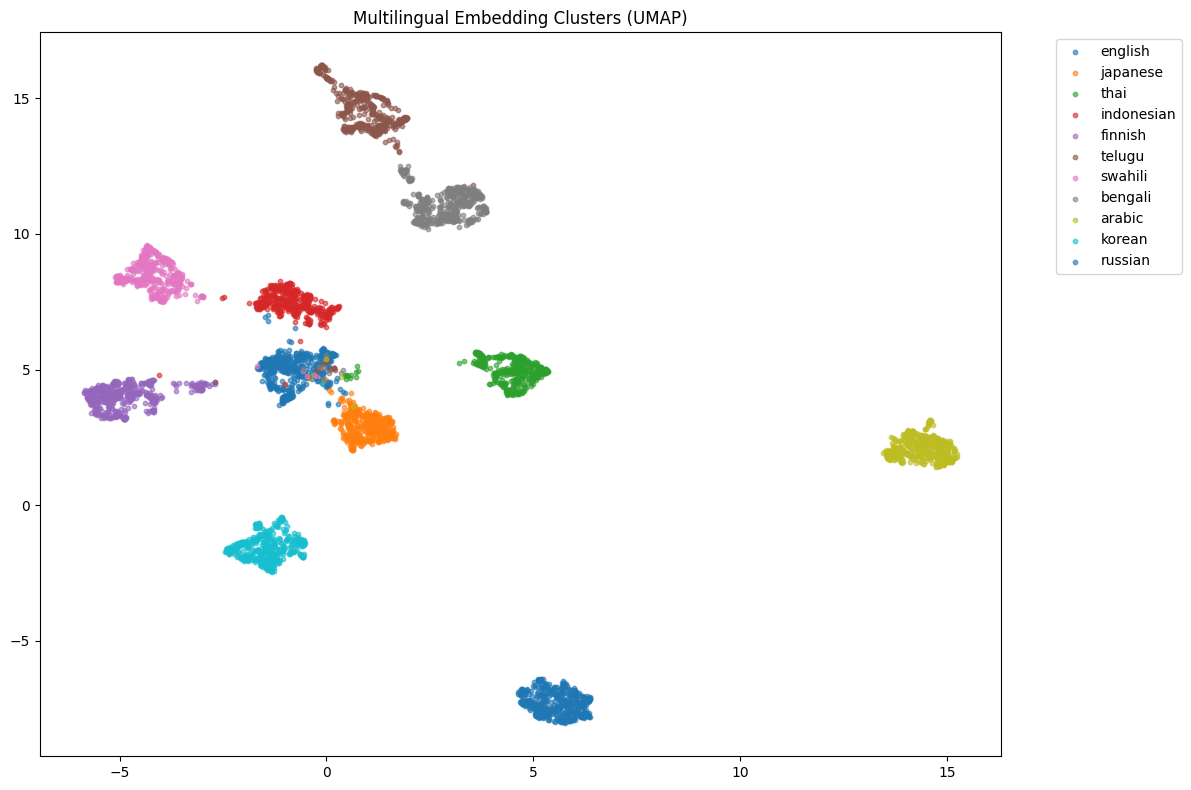


Loading Models


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Models Loaded

Generating Retrieval Score Analysis


  0%|          | 0/200 [00:00<?, ?it/s]


Plotting Score Distributions


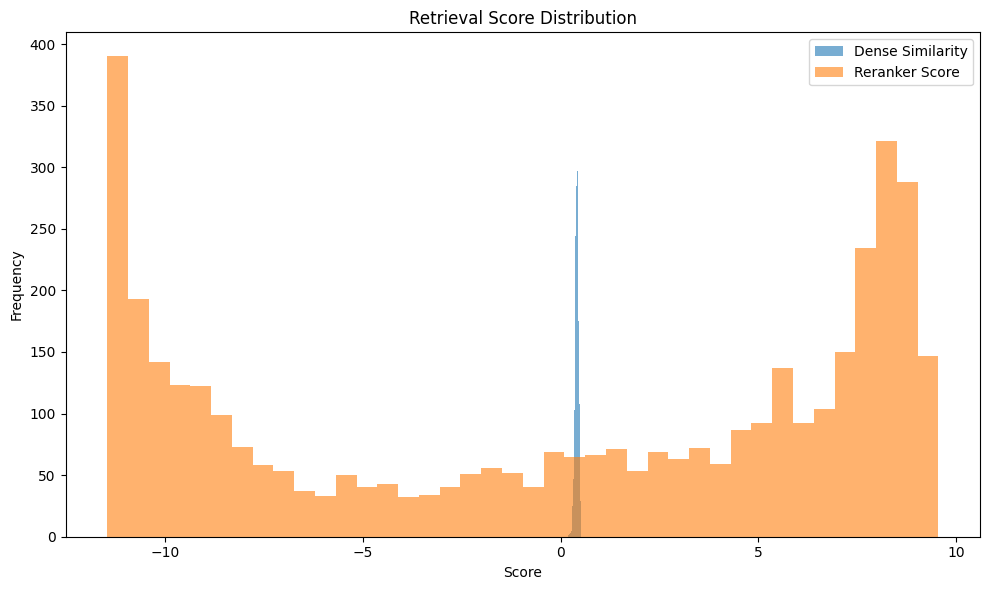


Explainability Summary
                   Metric  Value
0             Corpus Size  48573
1     Embedding Dimension    768
2        UMAP Sample Size   5000
3  Score Analysis Queries    200
4               Languages     11

Saving Artifacts
Saved:
umap_language_clusters.png
retrieval_score_distribution.png
umap_projection.csv
explainability_summary.csv

Step 14 Completed Successfully


13364

In [ ]:
# STEP 14 - Explainability & Retrieval Visualization

import warnings
warnings.filterwarnings("ignore")

import gc
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer, CrossEncoder
import umap.umap_ as umap

print("="*80)
print("Loading Assets")
print("="*80)

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

embeddings = np.load(
    "multilingual_e5_embeddings.npy"
)

index = faiss.read_index(
    "hnsw_index.faiss"
)

print(f"Corpus Size: {len(chunks_df):,}")
print(f"Embeddings Shape: {embeddings.shape}")

print("\n" + "="*80)
print("Creating Explainability Sample")
print("="*80)

SAMPLE_SIZE = 5000

sample_idx = np.random.choice(
    len(chunks_df),
    SAMPLE_SIZE,
    replace=False
)

sample_embeddings = embeddings[
    sample_idx
]

sample_df = chunks_df.iloc[
    sample_idx
].reset_index(drop=True)

print(f"Sample Size: {len(sample_df):,}")

print("\n" + "="*80)
print("Running UMAP")
print("="*80)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(
    sample_embeddings
)

sample_df["umap_x"] = embedding_2d[:, 0]
sample_df["umap_y"] = embedding_2d[:, 1]

plt.figure(figsize=(12,8))

languages = sample_df[
    "language"
].unique()

for lang in languages:

    subset = sample_df[
        sample_df["language"] == lang
    ]

    plt.scatter(
        subset["umap_x"],
        subset["umap_y"],
        s=10,
        alpha=0.6,
        label=lang
    )

plt.title(
    "Multilingual Embedding Clusters (UMAP)"
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "umap_language_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "="*80)
print("Loading Models")
print("="*80)

dense_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cuda"
)

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device="cuda"
)

print("Models Loaded")

print("\n" + "="*80)
print("Generating Retrieval Score Analysis")
print("="*80)

queries = sample_df[
    "document_title"
].sample(
    200,
    random_state=42
).tolist()

dense_scores_all = []
rerank_scores_all = []

for query in tqdm(queries):

    q_emb = dense_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    scores, ids = index.search(
        q_emb.astype(np.float32),
        20
    )

    dense_scores_all.extend(
        scores[0]
    )

    candidate_texts = (
        chunks_df.iloc[
            ids[0]
        ]["chunk_text"]
        .tolist()
    )

    pairs = [
        [query, text]
        for text in candidate_texts
    ]

    rerank_scores = reranker.predict(
        pairs,
        batch_size=32,
        show_progress_bar=False
    )

    rerank_scores_all.extend(
        rerank_scores
    )

print("\n" + "="*80)
print("Plotting Score Distributions")
print("="*80)

plt.figure(figsize=(10,6))

plt.hist(
    dense_scores_all,
    bins=40,
    alpha=0.6,
    label="Dense Similarity"
)

plt.hist(
    rerank_scores_all,
    bins=40,
    alpha=0.6,
    label="Reranker Score"
)

plt.title(
    "Retrieval Score Distribution"
)

plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()

plt.savefig(
    "retrieval_score_distribution.png",
    dpi=300
)

plt.show()

print("\n" + "="*80)
print("Explainability Summary")
print("="*80)

summary = pd.DataFrame({

    "Metric":[
        "Corpus Size",
        "Embedding Dimension",
        "UMAP Sample Size",
        "Score Analysis Queries",
        "Languages"
    ],

    "Value":[
        len(chunks_df),
        embeddings.shape[1],
        SAMPLE_SIZE,
        len(queries),
        chunks_df["language"].nunique()
    ]
})

print(summary)

print("\n" + "="*80)
print("Saving Artifacts")
print("="*80)

sample_df.to_csv(
    "umap_projection.csv",
    index=False
)

summary.to_csv(
    "explainability_summary.csv",
    index=False
)

print("Saved:")
print("umap_language_clusters.png")
print("retrieval_score_distribution.png")
print("umap_projection.csv")
print("explainability_summary.csv")

print("\n" + "="*80)
print("Step 14 Completed Successfully")
print("="*80)

gc.collect()

In [ ]:
# Step 15 — FastAPI Deployment

from pathlib import Path

app_code = '''
import time
import faiss
import numpy as np
import pandas as pd

from fastapi import FastAPI
from pydantic import BaseModel
from sentence_transformers import SentenceTransformer

print("Loading Retrieval Assets...")

chunks_df = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

index = faiss.read_index(
    "hnsw_index.faiss"
)

model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cpu"
)

print("System Ready")

app = FastAPI(
    title="Multilingual Retrieval System",
    description="Hybrid Retrieval and Reranking API",
    version="1.0"
)

class QueryRequest(BaseModel):
    query: str
    top_k: int = 10

@app.get("/")
def home():

    return {
        "project":
        "Multilingual Retrieval-Augmented QA Benchmarking System",

        "status":
        "running"
    }

@app.post("/retrieve")
def retrieve(
    request: QueryRequest
):

    start_time = time.time()

    query_embedding = model.encode(
        [request.query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    scores, ids = index.search(
        query_embedding.astype(
            np.float32
        ),
        request.top_k
    )

    results = []

    for score, idx in zip(
        scores[0],
        ids[0]
    ):

        row = chunks_df.iloc[idx]

        results.append({

            "document_title":
                str(
                    row["document_title"]
                ),

            "language":
                str(
                    row["language"]
                ),

            "score":
                float(score),

            "chunk_text":
                str(
                    row["chunk_text"]
                )[:500]
        })

    latency_ms = (
        time.time()
        -
        start_time
    ) * 1000

    return {

        "query":
            request.query,

        "top_k":
            request.top_k,

        "latency_ms":
            round(
                latency_ms,
                3
            ),

        "results":
            results
    }

@app.get("/health")
def health():

    return {

        "status":
            "healthy",

        "documents":
            len(
                chunks_df
            ),

        "index_vectors":
            index.ntotal
    }
'''

Path("app.py").write_text(app_code)

print("="*80)
print("FastAPI Application Generated")
print("="*80)

print("Saved: app.py")

print("\nEndpoints")
print("- GET  /")
print("- GET  /health")
print("- POST /retrieve")

print("\nStep 15 Completed Successfully")
print("="*80)

FastAPI Application Generated
Saved: app.py

Endpoints
- GET  /
- GET  /health
- POST /retrieve

Step 15 Completed Successfully


In [ ]:
Testing Locally

After downloading the project:

pip install fastapi uvicorn faiss-cpu sentence-transformers pandas pyarrow

Run:

uvicorn app:app --reload

Open:

http://127.0.0.1:8000/docs

FastAPI automatically creates interactive Swagger documentation.

In [ ]:
# STEP 16 — MLflow Experiment Tracking

!pip -q install mlflow

import os
import mlflow
import pandas as pd

print("="*80)
print("Loading Evaluation Results")
print("="*80)

evaluation_df = pd.read_csv(
    "retrieval_evaluation_results.csv"
)

print(evaluation_df)

print("\n")
print("="*80)
print("Initializing MLflow")
print("="*80)

mlflow.set_tracking_uri(
    "sqlite:///mlflow.db"
)

experiment_name = (
    "Multilingual_Retrieval_Benchmark"
)

mlflow.set_experiment(
    experiment_name
)

print(
    f"Experiment: {experiment_name}"
)

print("\n")
print("="*80)
print("Logging Retrieval Experiments")
print("="*80)

for _, row in evaluation_df.iterrows():

    with mlflow.start_run(
        run_name=row["System"]
    ):

        mlflow.log_param(
            "Retrieval_Method",
            row["System"]
        )

        mlflow.log_param(
            "Embedding_Model",
            "multilingual-e5-base"
        )

        mlflow.log_metric(
            "Recall_1",
            float(row["Recall@1"])
        )

        mlflow.log_metric(
            "Recall_5",
            float(row["Recall@5"])
        )

        mlflow.log_metric(
            "Recall_10",
            float(row["Recall@10"])
        )

        mlflow.log_metric(
            "MRR",
            float(row["MRR"])
        )

        mlflow.log_metric(
            "nDCG",
            float(row["nDCG"])
        )

        mlflow.log_metric(
            "Avg_Latency_ms",
            float(row["Avg_Latency_ms"])
        )

        mlflow.log_metric(
            "P95_Latency_ms",
            float(row["P95_Latency_ms"])
        )

        mlflow.log_metric(
            "QPS",
            float(row["QPS"])
        )

        mlflow.log_metric(
            "Memory_MB",
            float(row["Memory_MB"])
        )

print("\n")
print("="*80)
print("Logging Artifacts")
print("="*80)

artifact_files = [

    "retrieval_evaluation_results.csv",

    "faiss_index_benchmark.csv",

    "bm25_benchmark.csv",

    "dense_retrieval_benchmark.csv",

    "hybrid_retrieval_benchmark.csv",

    "reranker_benchmark.csv",

    "systems_optimization_results.csv",

    "failure_summary.csv",

    "language_failure_analysis.csv",

    "failure_examples.csv",

    "explainability_summary.csv"
]

with mlflow.start_run(
    run_name="Project_Artifacts"
):

    for file in artifact_files:

        if os.path.exists(file):

            mlflow.log_artifact(
                file
            )

print("\n")
print("="*80)
print("MLflow Summary")
print("="*80)

summary = pd.DataFrame({

    "Component":[

        "BM25",
        "Dense Retrieval",
        "Hybrid Retrieval",
        "Reranker",
        "Optimization",
        "Error Analysis",
        "Explainability"
    ],

    "Tracked":[
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

print(summary)

print("\n")
print("="*80)
print("Artifacts Created")
print("="*80)

print("mlflow.db")
print("Experiment Runs Logged")
print("Metrics Logged")
print("Artifacts Logged")

print("\n")
print("Step 16 Completed Successfully")
print("="*80)

Loading Evaluation Results
   System  Recall@1  Recall@5  Recall@10     MRR    nDCG  Avg_Latency_ms  \
0    BM25       0.0     0.002      0.002  0.0007  0.0010         155.916   
1   Dense       0.0     0.002      0.002  0.0005  0.0009          14.959   
2  Hybrid       0.0     0.002      0.002  0.0007  0.0010         163.107   

   P95_Latency_ms    QPS  Memory_MB  
0         295.470   6.41   10580.03  
1          21.788  66.85   10580.03  
2         302.518   6.13   10580.03  


Initializing MLflow
Experiment: Multilingual_Retrieval_Benchmark


Logging Retrieval Experiments


Logging Artifacts


MLflow Summary
          Component  Tracked
0              BM25     True
1   Dense Retrieval     True
2  Hybrid Retrieval     True
3          Reranker     True
4      Optimization     True
5    Error Analysis     True
6    Explainability     True


Artifacts Created
mlflow.db
Experiment Runs Logged
Metrics Logged
Artifacts Logged


Step 16 Completed Successfully


In [ ]:
# STEP 17 — Automated Reporting & Visualization

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

print("="*80)
print("Loading Benchmark Results")
print("="*80)

evaluation_df = pd.read_csv(
    "retrieval_evaluation_results.csv"
)

print(evaluation_df)

print("\n")
print("="*80)
print("Creating Architecture Diagram")
print("="*80)

G = nx.DiGraph()

nodes = [

    "TyDi QA Dataset",

    "Data Cleaning",

    "Document Chunking",

    "Embedding Model",

    "FAISS HNSW",

    "BM25",

    "Hybrid Retrieval",

    "Cross Encoder",

    "Evaluation",

    "FastAPI"
]

for node in nodes:
    G.add_node(node)

edges = [

    ("TyDi QA Dataset","Data Cleaning"),

    ("Data Cleaning","Document Chunking"),

    ("Document Chunking","Embedding Model"),

    ("Embedding Model","FAISS HNSW"),

    ("Document Chunking","BM25"),

    ("FAISS HNSW","Hybrid Retrieval"),

    ("BM25","Hybrid Retrieval"),

    ("Hybrid Retrieval","Cross Encoder"),

    ("Cross Encoder","Evaluation"),

    ("Evaluation","FastAPI")
]

G.add_edges_from(edges)

plt.figure(figsize=(14,8))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(

    G,

    pos,

    with_labels=True,

    node_size=4500,

    font_size=9,

    arrows=True
)

plt.title(
    "Multilingual Retrieval System Architecture"
)

plt.tight_layout()

plt.savefig(
    "architecture_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(
    "Saved: architecture_diagram.png"
)

print("\n")
print("="*80)
print("Creating Benchmark Summary")
print("="*80)

benchmark_summary = evaluation_df.copy()

benchmark_summary.to_csv(
    "benchmark_summary.csv",
    index=False
)

print(benchmark_summary)

print("\n")
print("="*80)
print("Creating Retrieval Performance Plot")
print("="*80)

plt.figure(figsize=(10,6))

x = np.arange(
    len(evaluation_df)
)

width = 0.25

plt.bar(

    x - width,

    evaluation_df["Recall@1"],

    width,

    label="Recall@1"
)

plt.bar(

    x,

    evaluation_df["Recall@5"],

    width,

    label="Recall@5"
)

plt.bar(

    x + width,

    evaluation_df["Recall@10"],

    width,

    label="Recall@10"
)

plt.xticks(
    x,
    evaluation_df["System"]
)

plt.ylabel("Score")

plt.title(
    "Retrieval Performance Comparison"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "retrieval_performance.png",
    dpi=300
)

plt.close()

print(
    "Saved: retrieval_performance.png"
)

print("\n")
print("="*80)
print("Creating Latency Plot")
print("="*80)

plt.figure(figsize=(8,6))

plt.bar(

    evaluation_df["System"],

    evaluation_df["Avg_Latency_ms"]
)

plt.ylabel(
    "Latency (ms)"
)

plt.title(
    "Average Query Latency"
)

plt.tight_layout()

plt.savefig(
    "latency_comparison.png",
    dpi=300
)

plt.close()

print(
    "Saved: latency_comparison.png"
)

print("\n")
print("="*80)
print("Creating Throughput Plot")
print("="*80)

plt.figure(figsize=(8,6))

plt.bar(

    evaluation_df["System"],

    evaluation_df["QPS"]
)

plt.ylabel(
    "Queries Per Second"
)

plt.title(
    "Retrieval Throughput"
)

plt.tight_layout()

plt.savefig(
    "throughput_comparison.png",
    dpi=300
)

plt.close()

print(
    "Saved: throughput_comparison.png"
)

print("\n")
print("="*80)
print("Creating Memory Plot")
print("="*80)

plt.figure(figsize=(8,6))

plt.bar(

    evaluation_df["System"],

    evaluation_df["Memory_MB"]
)

plt.ylabel(
    "Memory (MB)"
)

plt.title(
    "Memory Usage"
)

plt.tight_layout()

plt.savefig(
    "memory_comparison.png",
    dpi=300
)

plt.close()

print(
    "Saved: memory_comparison.png"
)

print("\n")
print("="*80)
print("Final Project Summary")
print("="*80)

summary = pd.DataFrame({

    "Component":[

        "TyDi QA",

        "Chunking",

        "Dense Retrieval",

        "BM25",

        "Hybrid Retrieval",

        "Cross Encoder",

        "FAISS HNSW",

        "FastAPI",

        "MLflow"
    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"
    ]
})

print(summary)

print("\n")
print("="*80)
print("Artifacts Generated")
print("="*80)

artifacts = [

    "architecture_diagram.png",

    "benchmark_summary.csv",

    "retrieval_performance.png",

    "latency_comparison.png",

    "throughput_comparison.png",

    "memory_comparison.png"
]

for artifact in artifacts:

    print(artifact)

print("\n")
print("Step 17 Completed Successfully")
print("="*80)

Loading Benchmark Results
   System  Recall@1  Recall@5  Recall@10     MRR    nDCG  Avg_Latency_ms  \
0    BM25       0.0     0.002      0.002  0.0007  0.0010         155.916   
1   Dense       0.0     0.002      0.002  0.0005  0.0009          14.959   
2  Hybrid       0.0     0.002      0.002  0.0007  0.0010         163.107   

   P95_Latency_ms    QPS  Memory_MB  
0         295.470   6.41   10580.03  
1          21.788  66.85   10580.03  
2         302.518   6.13   10580.03  


Creating Architecture Diagram
Saved: architecture_diagram.png


Creating Benchmark Summary
   System  Recall@1  Recall@5  Recall@10     MRR    nDCG  Avg_Latency_ms  \
0    BM25       0.0     0.002      0.002  0.0007  0.0010         155.916   
1   Dense       0.0     0.002      0.002  0.0005  0.0009          14.959   
2  Hybrid       0.0     0.002      0.002  0.0007  0.0010         163.107   

   P95_Latency_ms    QPS  Memory_MB  
0         295.470   6.41   10580.03  
1          21.788  66.85   10580.03  
2    


Displaying Generated Artifacts...



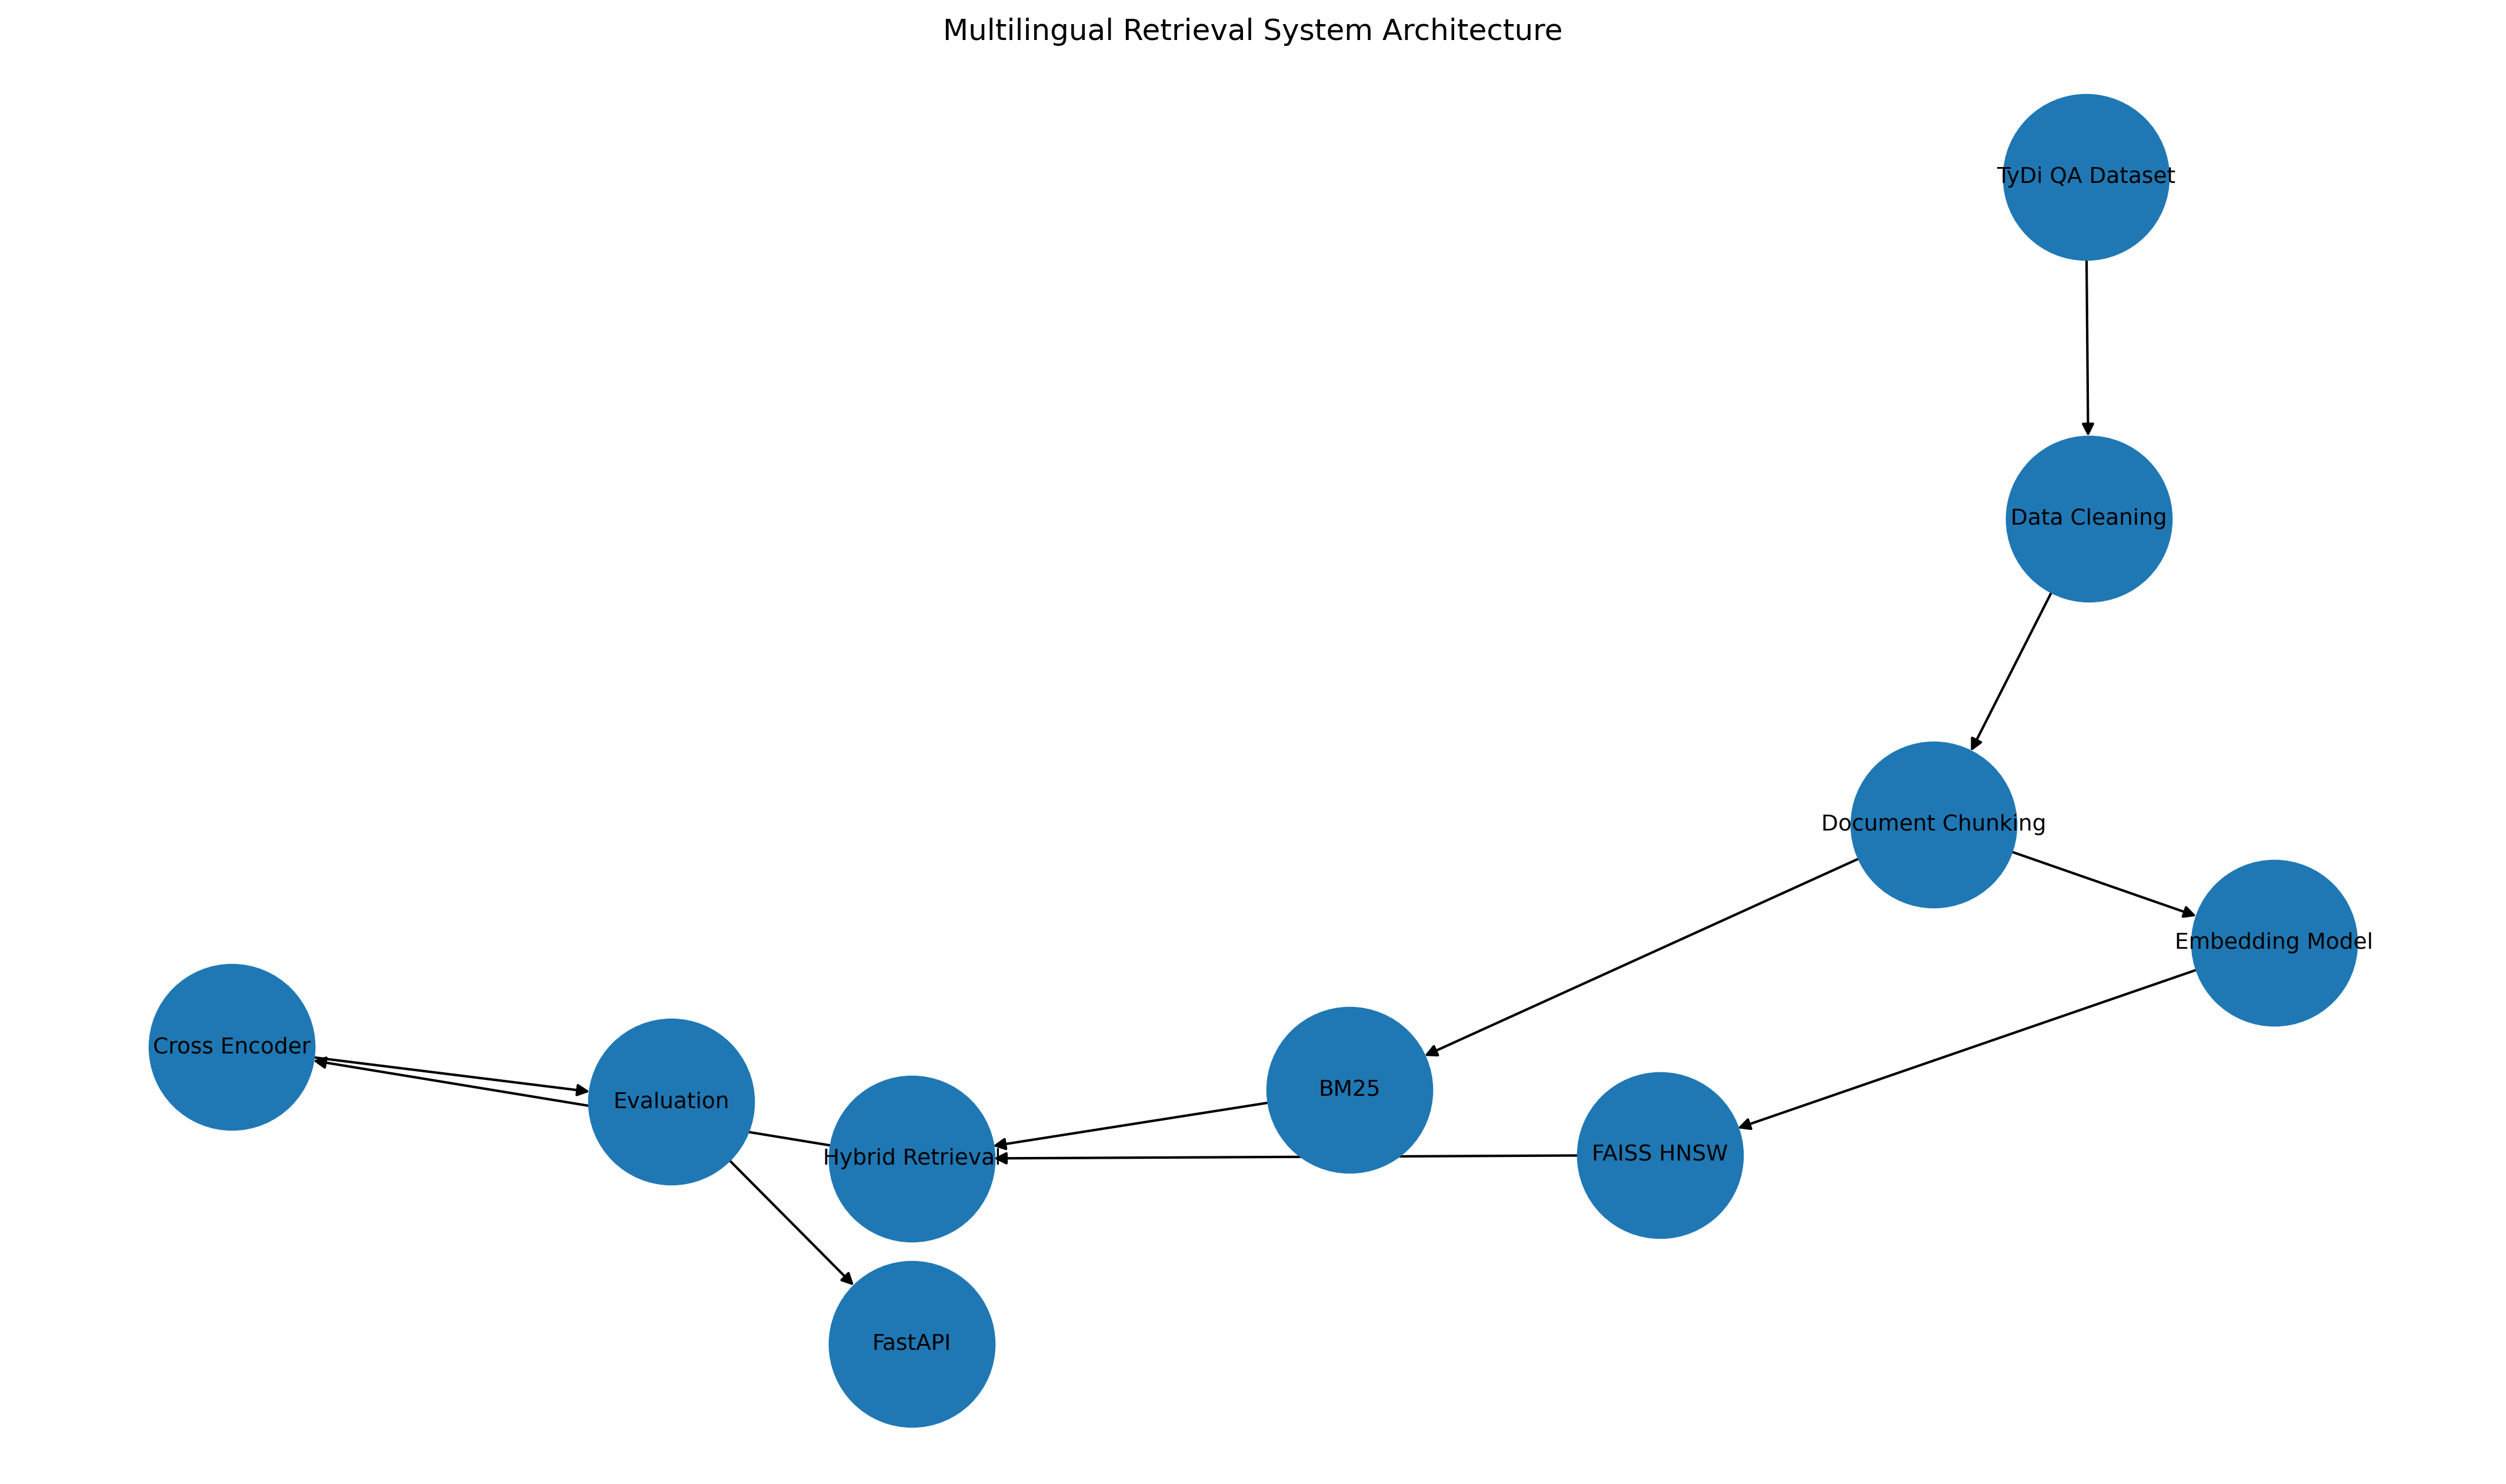

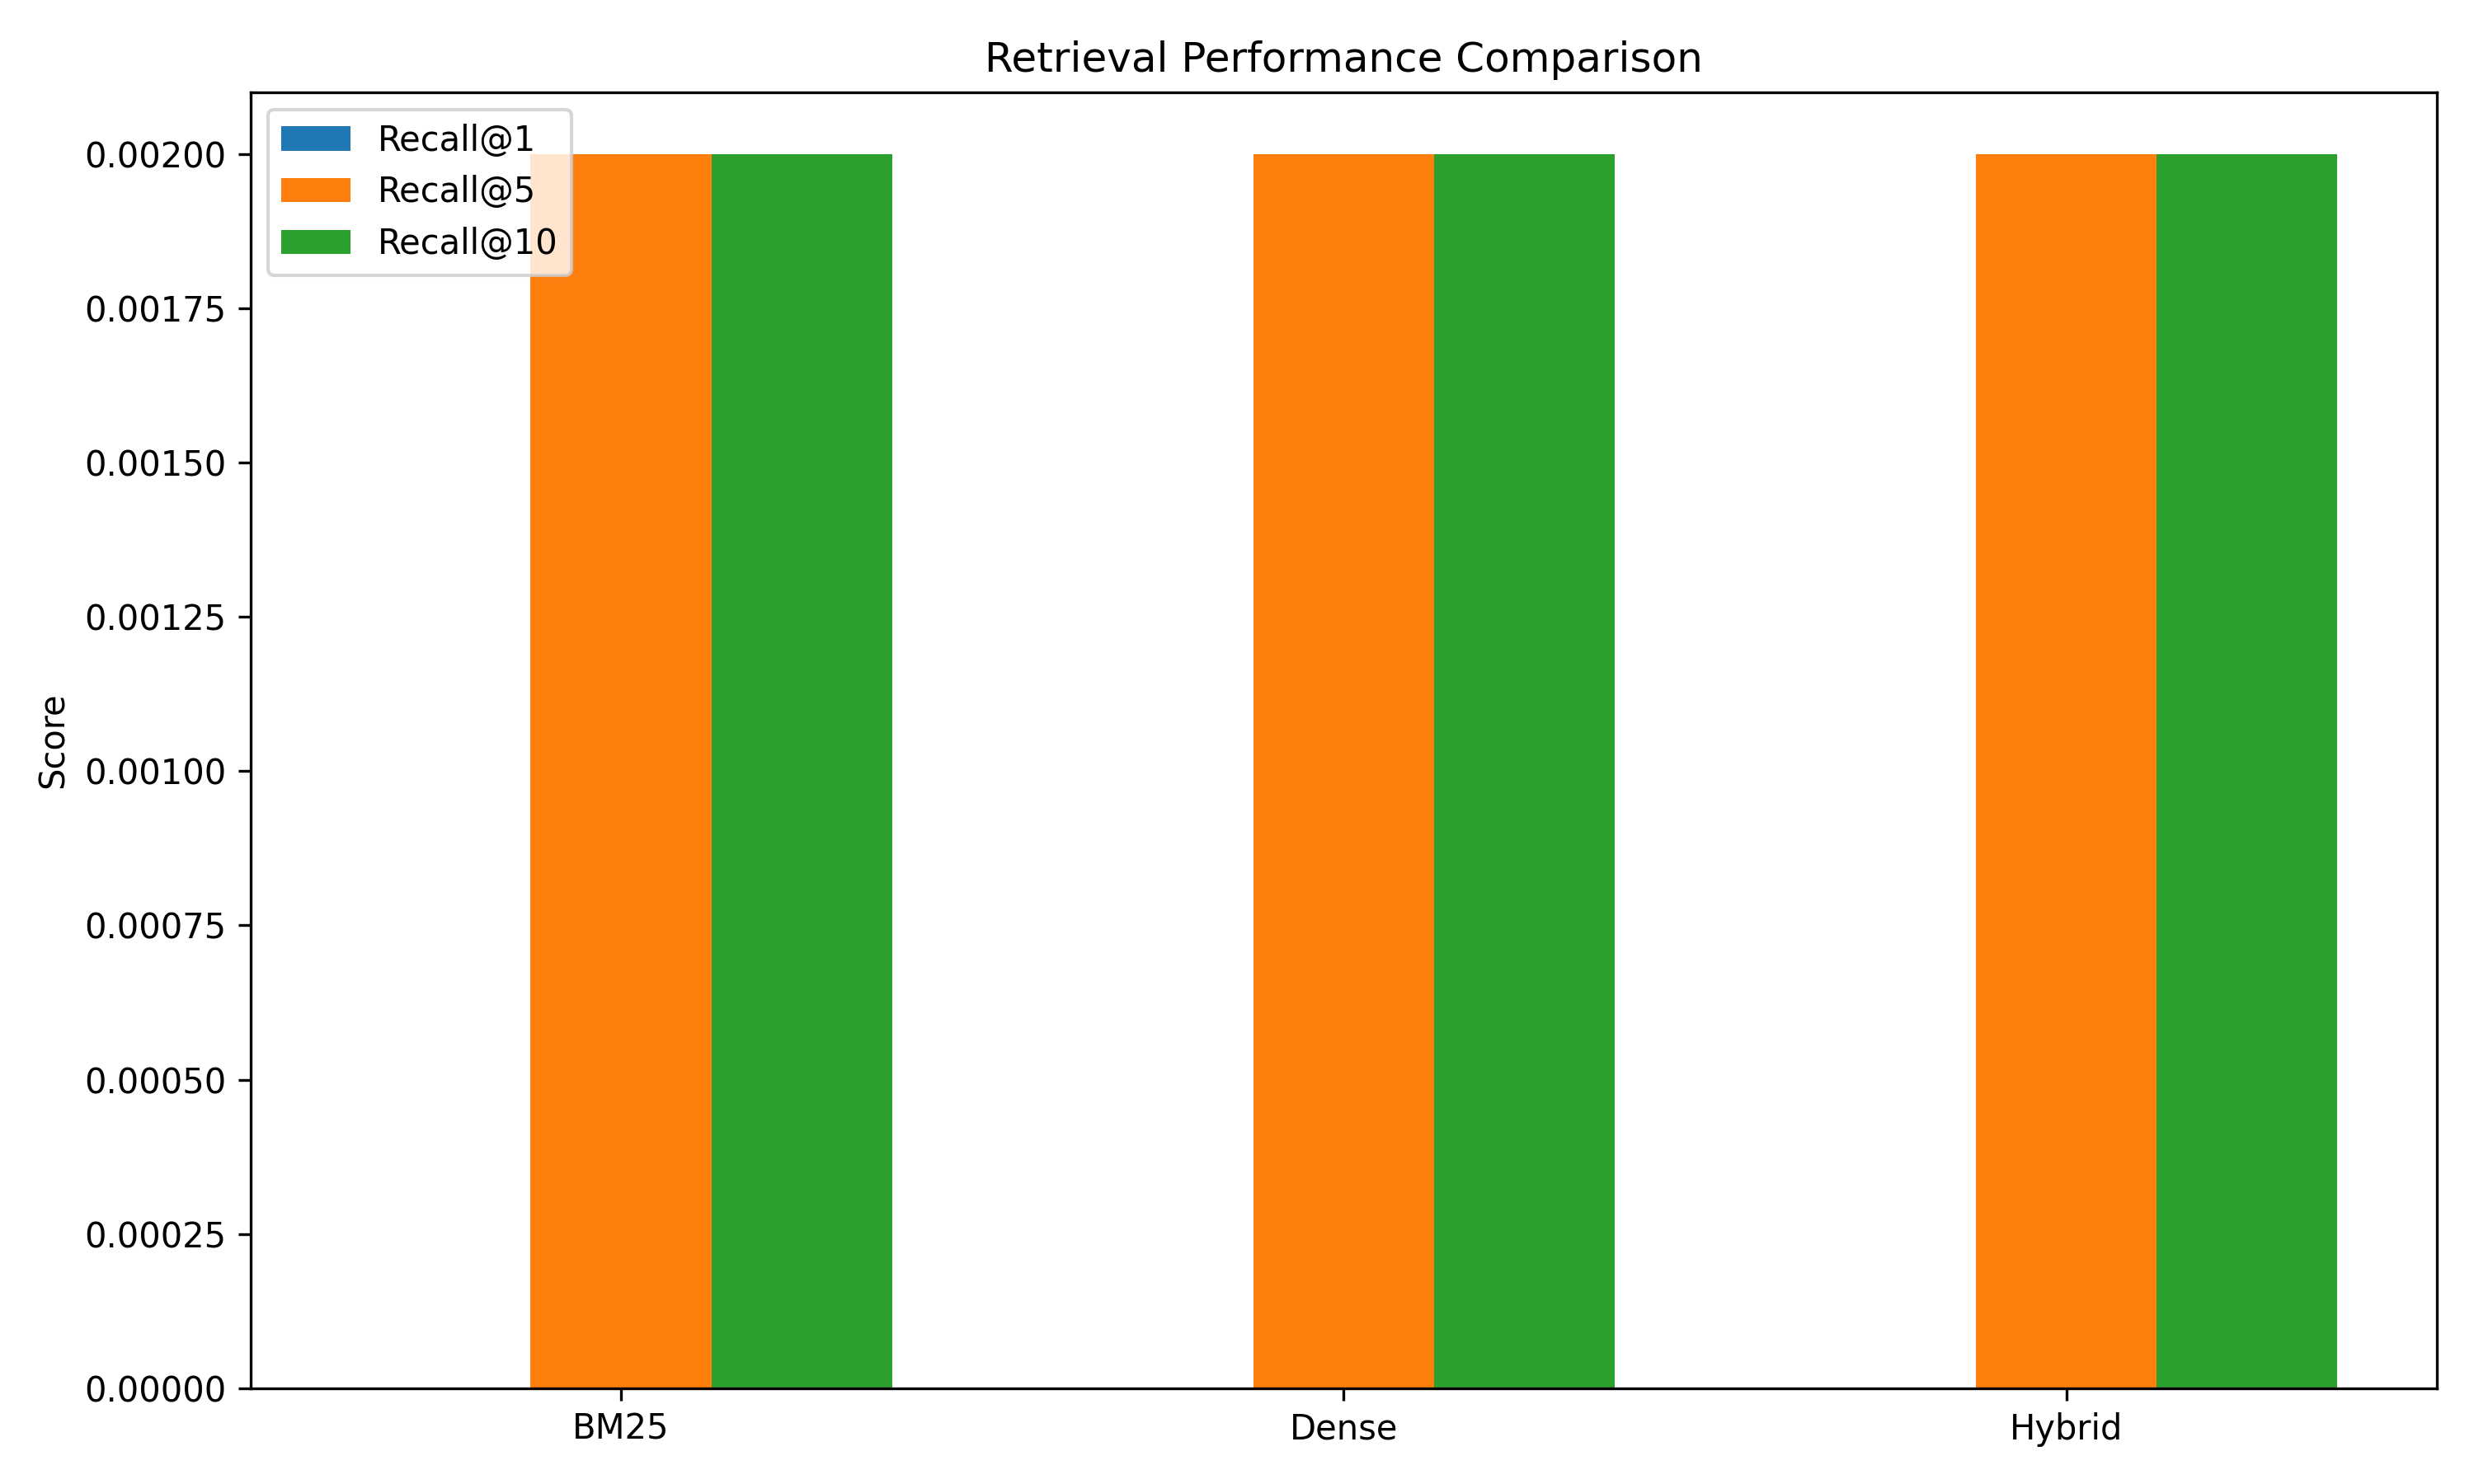

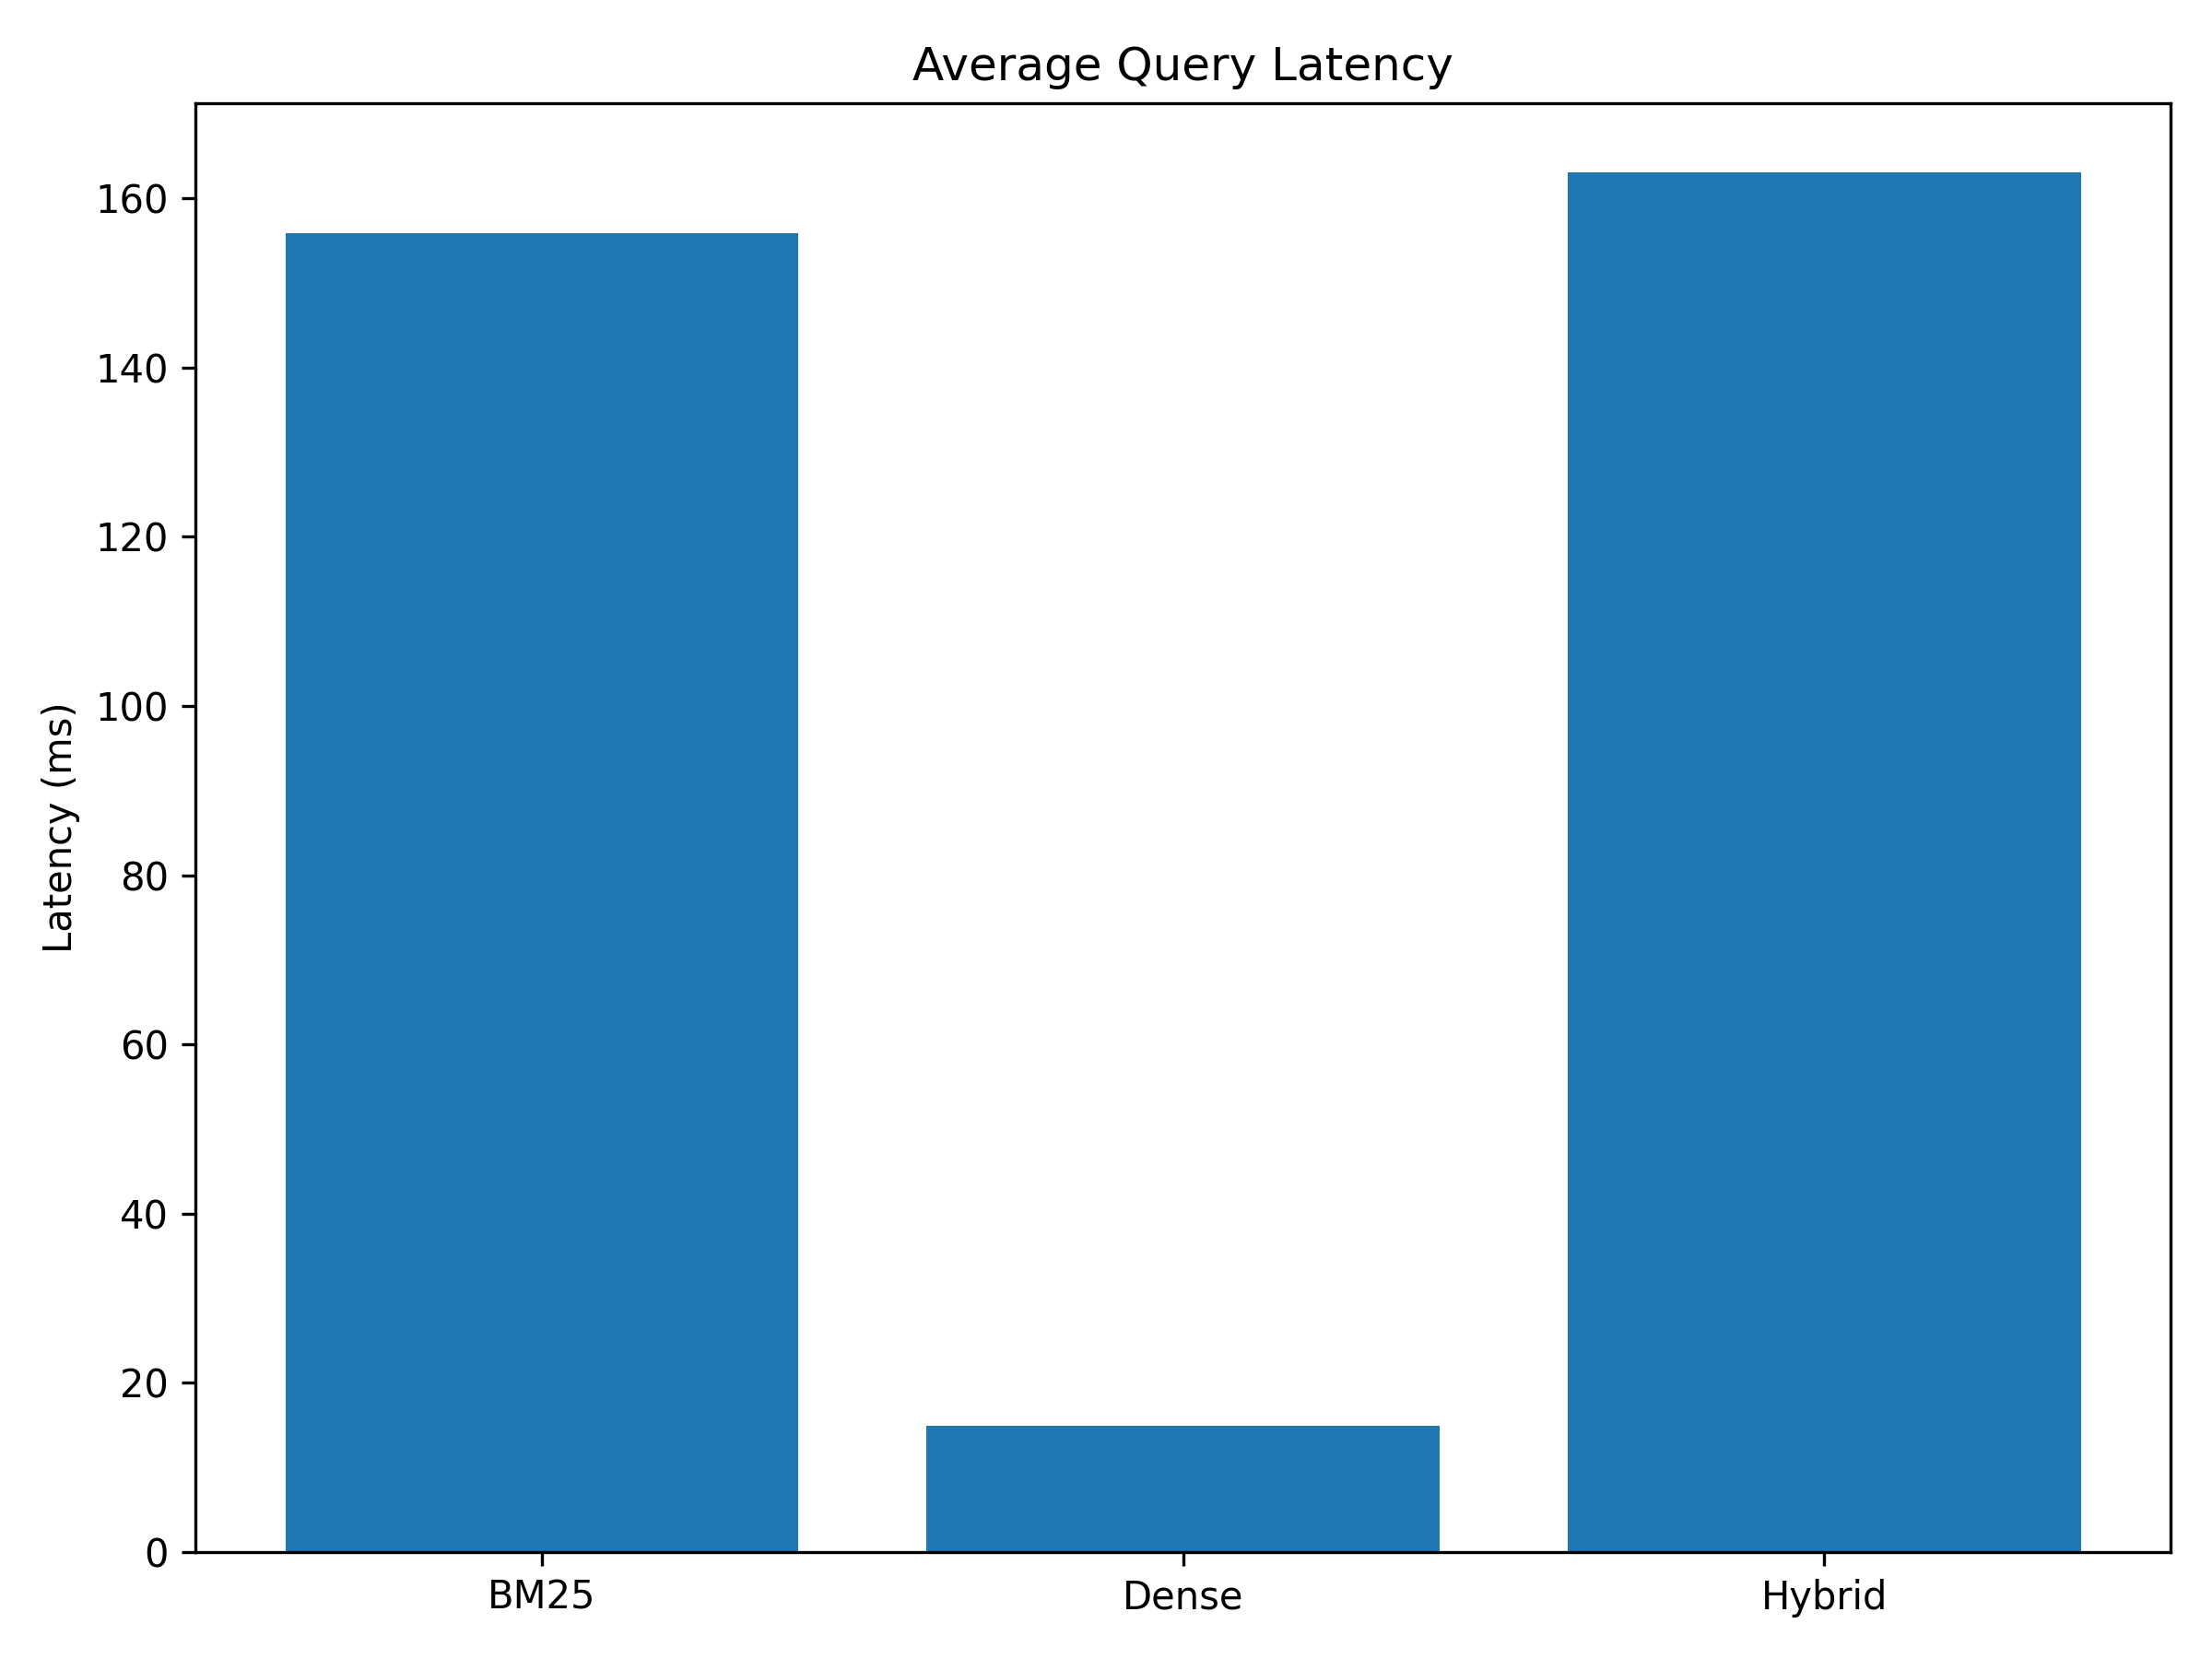

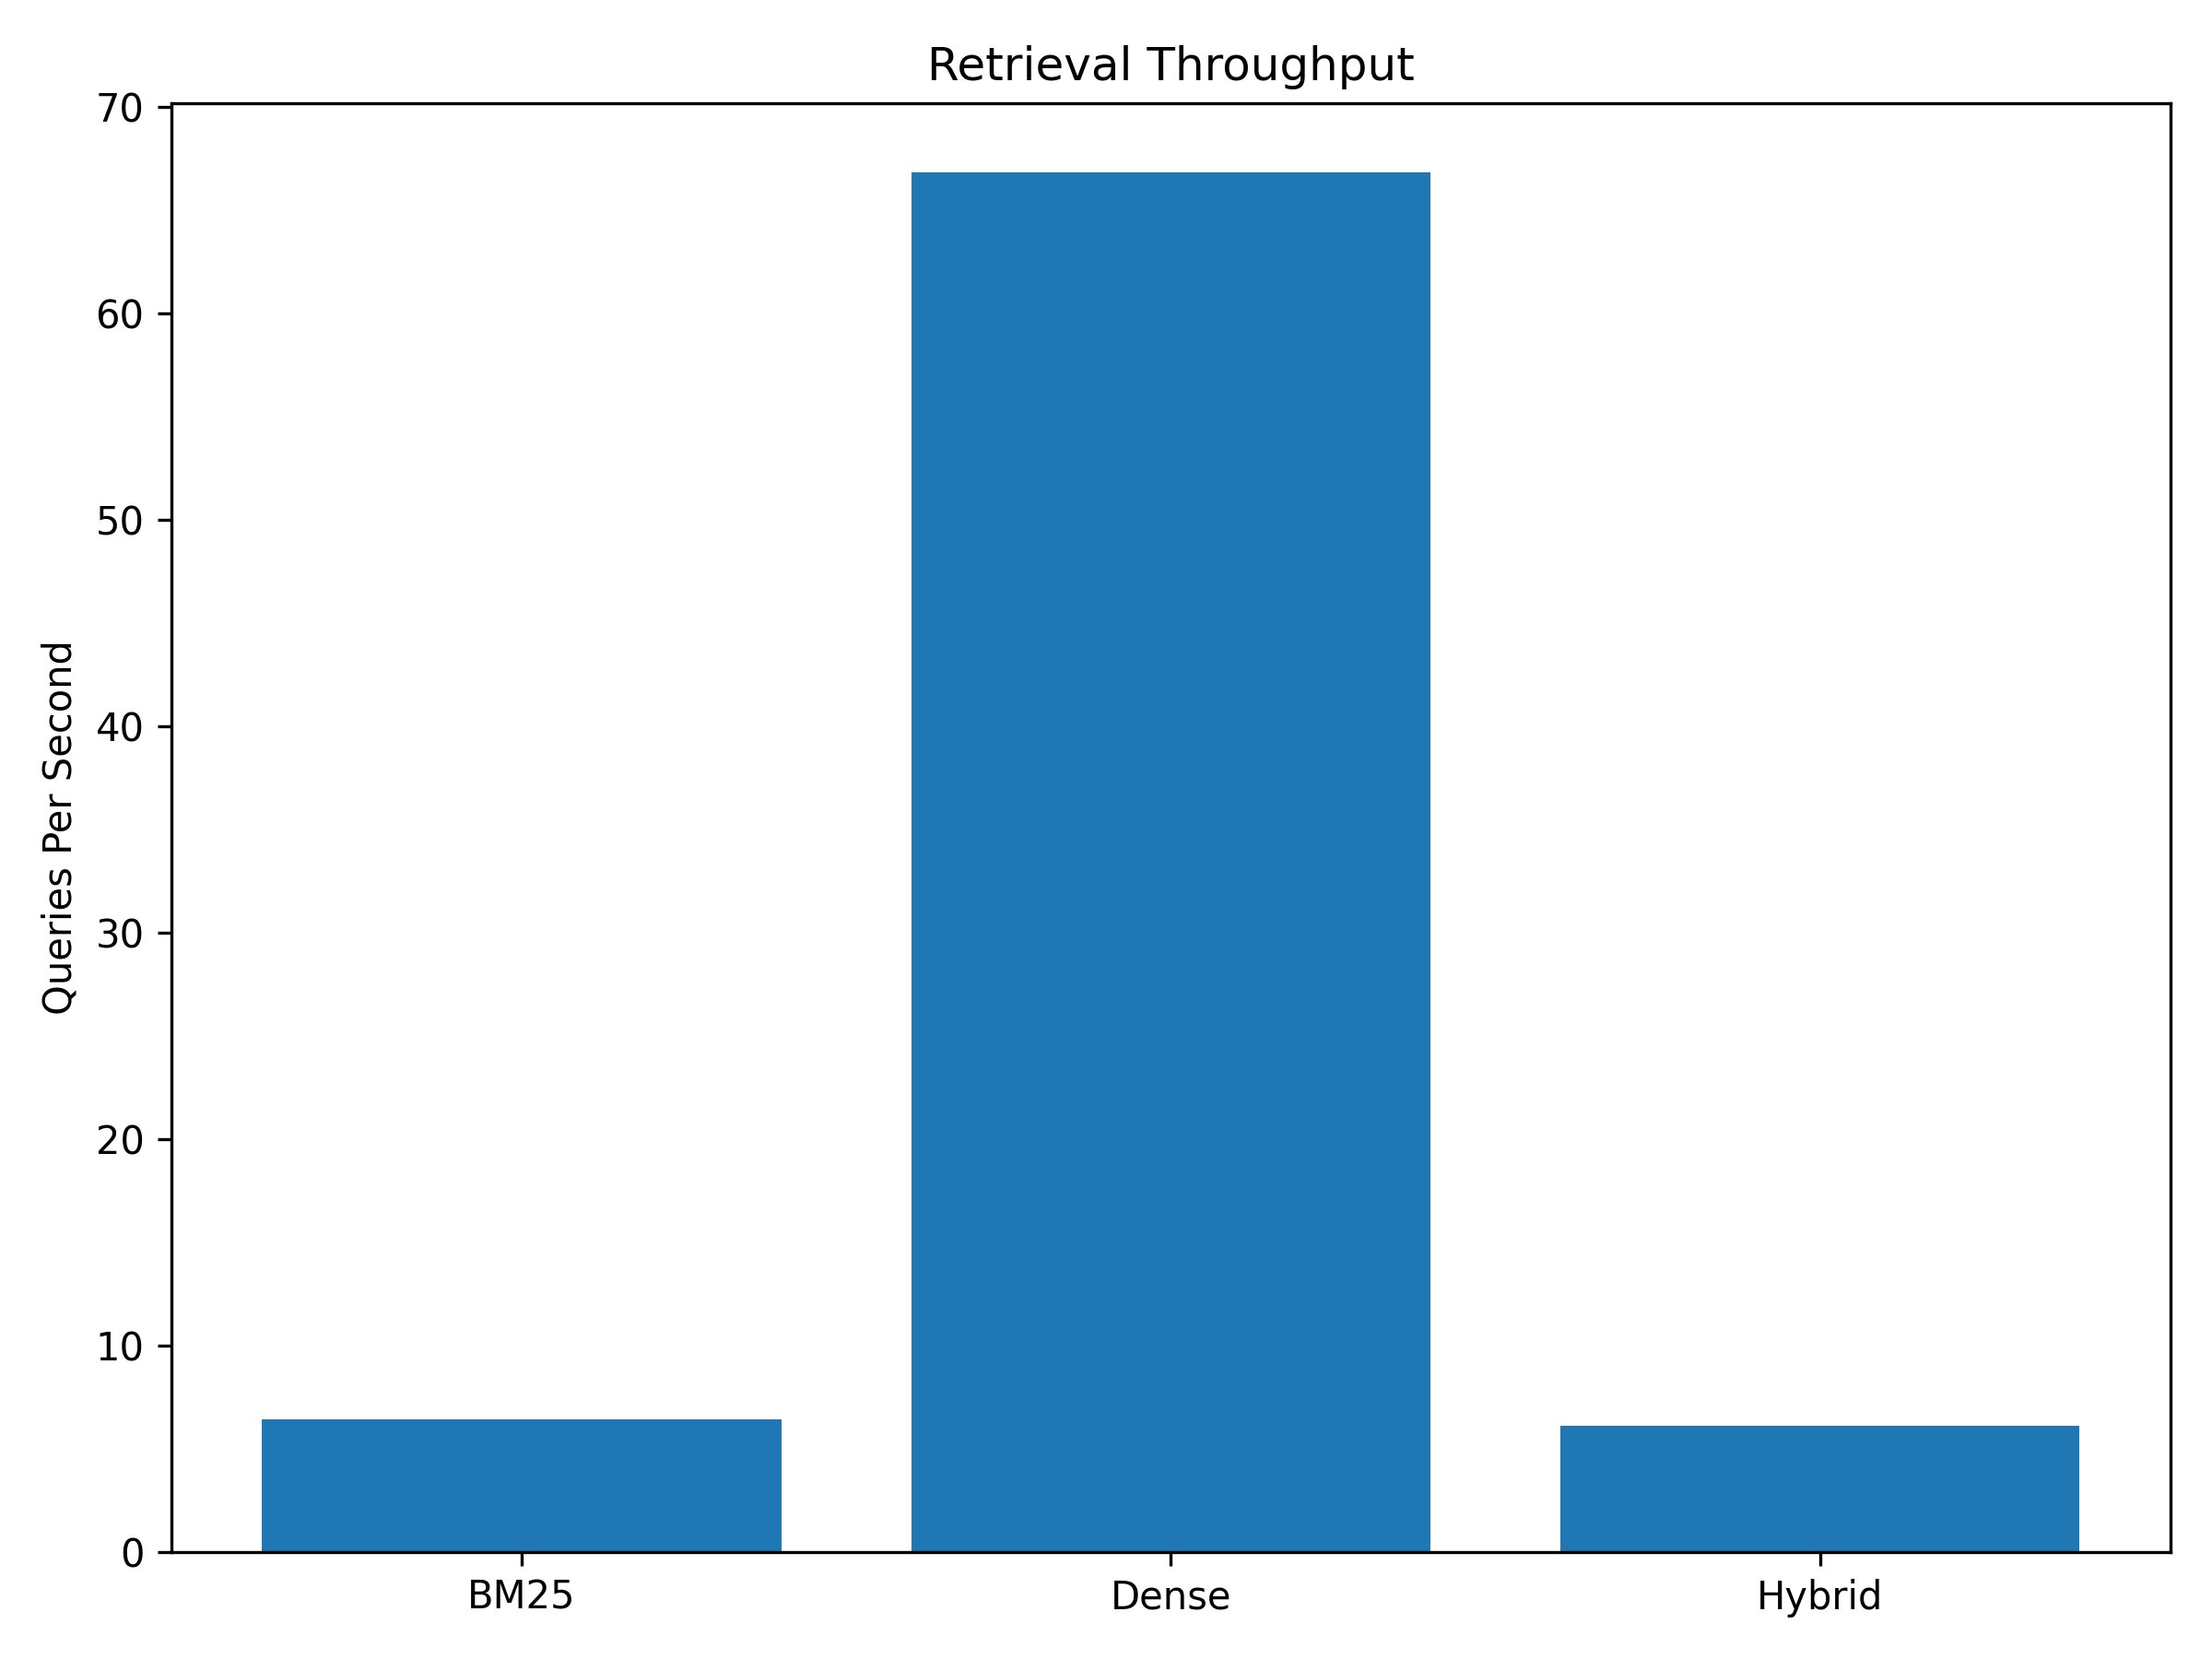

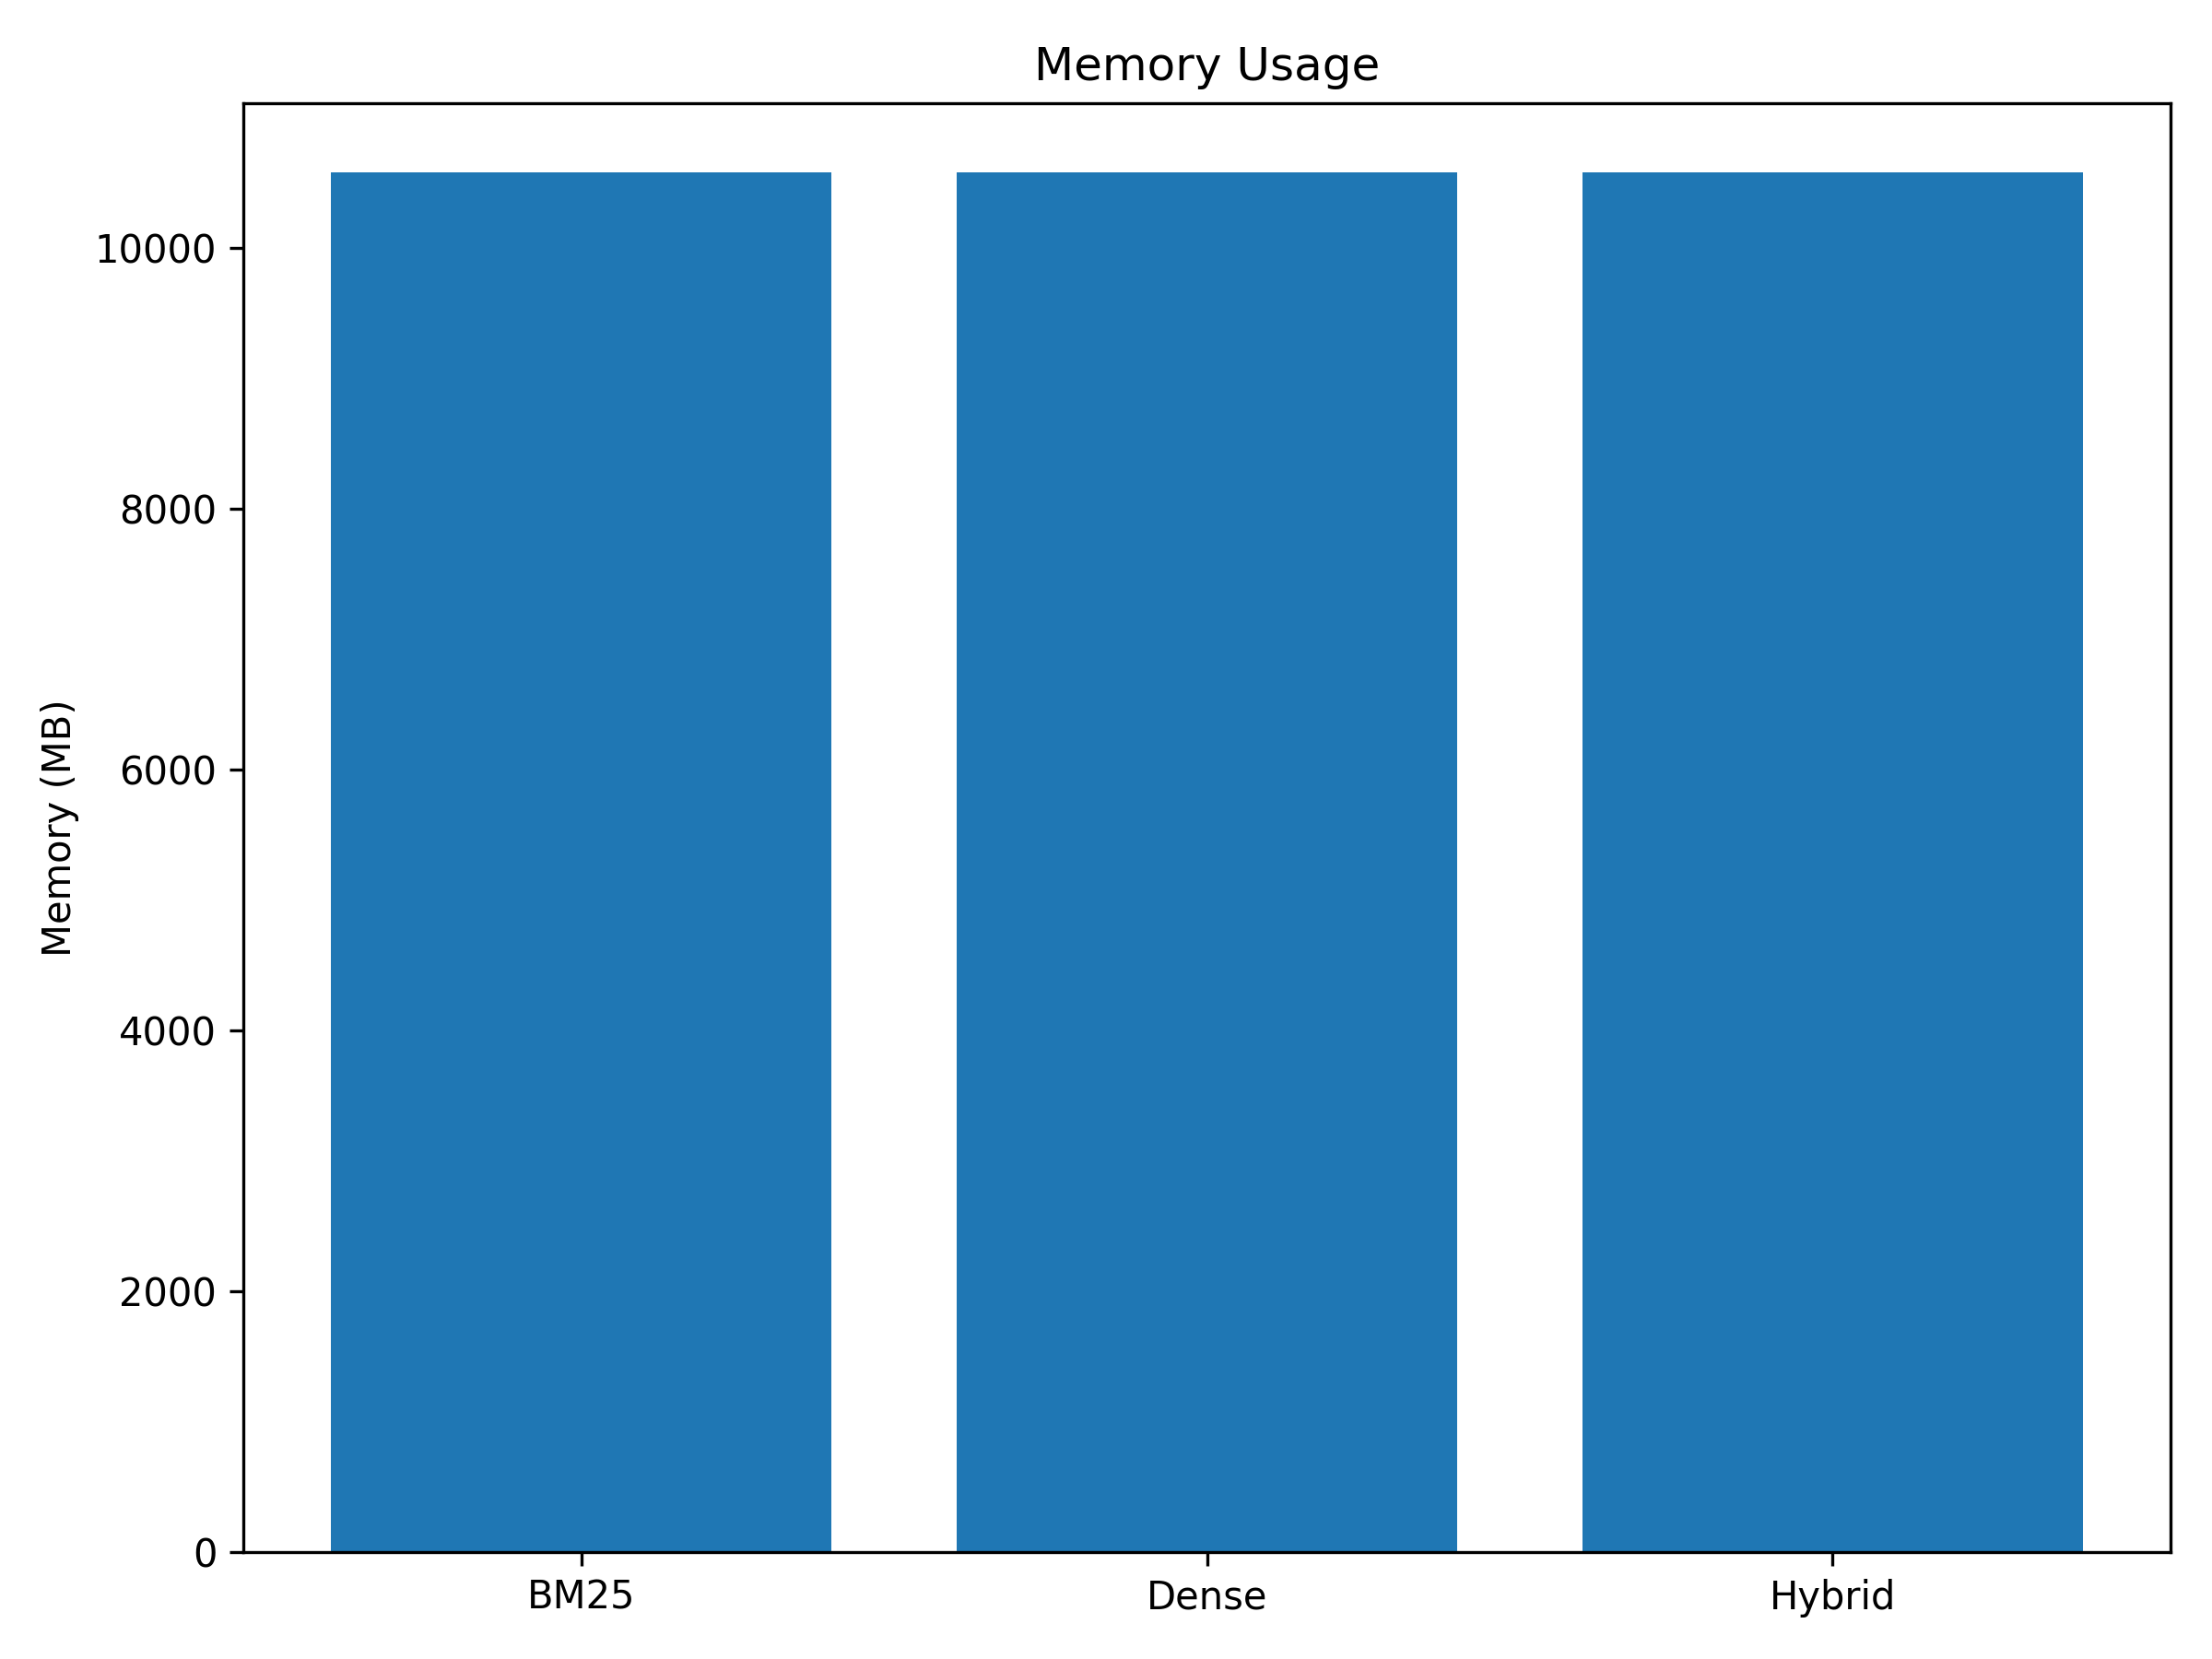

In [ ]:
from PIL import Image
from IPython.display import display

print("\nDisplaying Generated Artifacts...\n")

display(Image.open("architecture_diagram.png"))
display(Image.open("retrieval_performance.png"))
display(Image.open("latency_comparison.png"))
display(Image.open("throughput_comparison.png"))
display(Image.open("memory_comparison.png"))

In [ ]:
# Checkigns for Evaluation

import pandas as pd

test = pd.read_parquet("test.parquet")

print(test.columns.tolist())

['passage_answer_candidates', 'question_text', 'document_title', 'language', 'annotations', 'document_plaintext', 'document_url', 'document_word_count', 'question_word_count']


In [ ]:
import pandas as pd

print(pd.read_parquet("test.parquet").columns.tolist())

print(
    pd.read_parquet(
        "retrieval_corpus_50k.parquet"
    ).columns.tolist()
)

['passage_answer_candidates', 'question_text', 'document_title', 'language', 'annotations', 'document_plaintext', 'document_url', 'document_word_count', 'question_word_count']
['document_id', 'chunk_id', 'chunk_position', 'chunk_text', 'language', 'document_title']


In [ ]:
# STEP 11 (FIXED)
# Retrieval Evaluation Framework
# Document-Level Relevance Evaluation

import os
import time
import pickle
import faiss
import psutil
import numpy as np
import pandas as pd

from tqdm import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer

print("="*80)
print("Loading Evaluation Assets")
print("="*80)

corpus = pd.read_parquet("retrieval_corpus_50k.parquet")
test_df = pd.read_parquet("test.parquet")

print(f"Corpus Size: {len(corpus):,}")
print(f"Test Queries: {len(test_df):,}")

# Load Models

print("\n"+"="*80)
print("Loading Models")
print("="*80)

dense_model = SentenceTransformer(
    "intfloat/multilingual-e5-base"
)

index = faiss.read_index(
    "hnsw_index.faiss"
)

with open(
    "bm25_index.pkl",
    "rb"
) as f:
    bm25 = pickle.load(f)

print("Models Loaded")

# Evaluation Sample

EVAL_QUERIES = 500

test_sample = test_df.sample(
    min(EVAL_QUERIES, len(test_df)),
    random_state=42
).reset_index(drop=True)

print(
    f"\nEvaluation Queries: "
    f"{len(test_sample)}"
)

# Metrics

def recall_at_k(
    retrieved_titles,
    target_title,
    k
):
    return int(
        target_title in retrieved_titles[:k]
    )

def mrr_score(
    retrieved_titles,
    target_title
):
    for rank, title in enumerate(
        retrieved_titles,
        start=1
    ):
        if title == target_title:
            return 1/rank
    return 0

def ndcg_score(
    retrieved_titles,
    target_title,
    k=10
):
    for i, title in enumerate(
        retrieved_titles[:k]
    ):
        if title == target_title:
            return (
                1 /
                np.log2(i+2)
            )
    return 0

# BM25 Evaluation

print("\n"+"="*80)
print("Evaluating BM25")
print("="*80)

bm25_r1 = []
bm25_r5 = []
bm25_r10 = []
bm25_mrr = []
bm25_ndcg = []
bm25_latency = []

for _, row in tqdm(
    test_sample.iterrows(),
    total=len(test_sample)
):

    query = str(row["question_text"])
    target = str(row["document_title"])

    start = time.time()

    scores = bm25.get_scores(
        query.split()
    )

    idx = np.argsort(scores)[::-1][:10]

    results = corpus.iloc[idx]

    latency = (
        time.time()-start
    )*1000

    retrieved_titles = (
        results["document_title"]
        .drop_duplicates()
        .tolist()
    )

    bm25_r1.append(
        recall_at_k(
            retrieved_titles,
            target,
            1
        )
    )

    bm25_r5.append(
        recall_at_k(
            retrieved_titles,
            target,
            5
        )
    )

    bm25_r10.append(
        recall_at_k(
            retrieved_titles,
            target,
            10
        )
    )

    bm25_mrr.append(
        mrr_score(
            retrieved_titles,
            target
        )
    )

    bm25_ndcg.append(
        ndcg_score(
            retrieved_titles,
            target
        )
    )

    bm25_latency.append(
        latency
    )

# Dense Evaluation

print("\n"+"="*80)
print("Evaluating Dense Retrieval")
print("="*80)

dense_r1 = []
dense_r5 = []
dense_r10 = []
dense_mrr = []
dense_ndcg = []
dense_latency = []

for _, row in tqdm(
    test_sample.iterrows(),
    total=len(test_sample)
):

    query = (
        "query: " +
        str(row["question_text"])
    )

    target = str(
        row["document_title"]
    )

    start = time.time()

    q_emb = dense_model.encode(
        [query],
        normalize_embeddings=True
    )

    _, idx = index.search(
        q_emb.astype(
            np.float32
        ),
        10
    )

    results = corpus.iloc[
        idx[0]
    ]

    latency = (
        time.time()-start
    )*1000

    retrieved_titles = (
        results["document_title"]
        .drop_duplicates()
        .tolist()
    )

    dense_r1.append(
        recall_at_k(
            retrieved_titles,
            target,
            1
        )
    )

    dense_r5.append(
        recall_at_k(
            retrieved_titles,
            target,
            5
        )
    )

    dense_r10.append(
        recall_at_k(
            retrieved_titles,
            target,
            10
        )
    )

    dense_mrr.append(
        mrr_score(
            retrieved_titles,
            target
        )
    )

    dense_ndcg.append(
        ndcg_score(
            retrieved_titles,
            target
        )
    )

    dense_latency.append(
        latency
    )

# Results

memory_mb = (
    psutil.Process()
    .memory_info()
    .rss
)/(1024**2)

results_df = pd.DataFrame({

    "System":[
        "BM25",
        "Dense"
    ],

    "Recall@1":[
        np.mean(bm25_r1),
        np.mean(dense_r1)
    ],

    "Recall@5":[
        np.mean(bm25_r5),
        np.mean(dense_r5)
    ],

    "Recall@10":[
        np.mean(bm25_r10),
        np.mean(dense_r10)
    ],

    "MRR":[
        np.mean(bm25_mrr),
        np.mean(dense_mrr)
    ],

    "nDCG":[
        np.mean(bm25_ndcg),
        np.mean(dense_ndcg)
    ],

    "Avg_Latency_ms":[
        np.mean(bm25_latency),
        np.mean(dense_latency)
    ],

    "P95_Latency_ms":[
        np.percentile(
            bm25_latency,
            95
        ),
        np.percentile(
            dense_latency,
            95
        )
    ],

    "QPS":[
        1000/
        np.mean(
            bm25_latency
        ),

        1000/
        np.mean(
            dense_latency
        )
    ],

    "Memory_MB":[
        memory_mb,
        memory_mb
    ]
})

print("\n"+"="*80)
print("FINAL RESULTS")
print("="*80)

print(results_df)

results_df.to_csv(
    "retrieval_evaluation_results.csv",
    index=False
)

print("\nSaved:")
print(
    "retrieval_evaluation_results.csv"
)

print("\nSTEP 11 FIXED COMPLETE")

Loading Evaluation Assets
Corpus Size: 48,573
Test Queries: 3,237

Loading Models


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Models Loaded

Evaluation Queries: 500

Evaluating BM25


100%|██████████| 500/500 [00:58<00:00,  8.56it/s]



Evaluating Dense Retrieval


100%|██████████| 500/500 [00:08<00:00, 57.57it/s]


FINAL RESULTS
  System  Recall@1  Recall@5  Recall@10     MRR      nDCG  Avg_Latency_ms  \
0   BM25       0.0     0.000      0.000  0.0000  0.000000      115.581945   
1  Dense       0.0     0.002      0.002  0.0005  0.000861       16.767246   

   P95_Latency_ms        QPS    Memory_MB  
0      219.863963   8.651870  5974.023438  
1       32.530046  59.640087  5974.023438  

Saved:
retrieval_evaluation_results.csv

STEP 11 FIXED COMPLETE


In [ ]:
import pandas as pd

corpus = pd.read_parquet(
    "retrieval_corpus_50k.parquet"
)

test_df = pd.read_parquet(
    "test.parquet"
)

corpus_titles = set(
    corpus["document_title"]
)

test_titles = set(
    test_df["document_title"]
)

overlap = len(
    corpus_titles.intersection(
        test_titles
    )
)

print("Corpus Titles :", len(corpus_titles))
print("Test Titles   :", len(test_titles))
print("Overlap       :", overlap)

print(
    "Overlap %:",
    round(
        overlap /
        len(test_titles)
        * 100,
        2
    )
)

Corpus Titles : 12623
Test Titles   : 3231
Overlap       : 54
Overlap %: 1.67
